# Online Retail Dataset — Exploratory Data Analysis

Dataset columns: `InvoiceNo`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, `Country`

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# encoding='utf-8-sig' strips the BOM character from the first column name
df = pd.read_csv('Online Retail(1).csv', encoding='utf-8-sig', parse_dates=['InvoiceDate'], dayfirst=True)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 1. Data Types & Basic Info

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


**Insights — Data Types**
- `InvoiceDate` is correctly parsed as datetime — no conversion needed.
- `CustomerID` is stored as `float64` instead of an integer because it contains NaN values; should be treated as a categorical identifier.
- `Quantity` and `UnitPrice` are numeric — allow direct aggregation.
- All text fields (`InvoiceNo`, `StockCode`, `Description`, `Country`) are `object` — watch for inconsistent casing or whitespace.

**Actionable**
- Cast `CustomerID` to `Int64` (nullable integer) or `str` before grouping to avoid floating-point IDs like `17850.0`.
- Validate `StockCode` format — non-numeric codes (e.g. `POST`, `DOT`) indicate service charges, not products, and may need to be excluded from product-level analysis.

## 2. Missing Values

In [40]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Missing %
Description,1454,0.27
CustomerID,135080,24.93


**Insights — Missing Values**
- **CustomerID is missing in ~25% of rows (135,080 rows)** — this is the biggest data quality issue. These are likely guest checkouts or point-of-sale transactions where customer identity was not captured.
- `Description` is missing in only 1,454 rows (~0.3%) — minor issue, likely data entry gaps.

**Actionable**
- Do **not** drop missing-CustomerID rows blindly for all analyses — they still contain valid transaction data (product, quantity, revenue).
- For **customer segmentation (RFM/clustering)**, these rows must be excluded since they cannot be tied to an individual.
- For **product or revenue analysis**, retain them — they represent real sales volume.
- Investigate whether missing CustomerIDs are concentrated in specific countries or time periods, which could indicate a systemic capture failure.

### Missing CustomerID — By Country

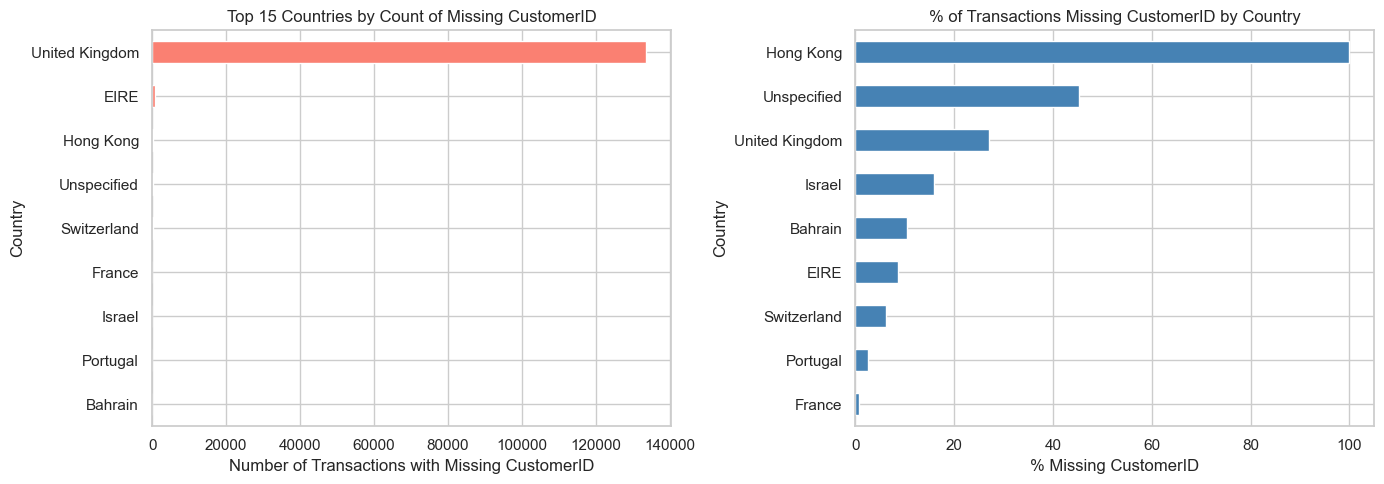

In [41]:
missing_by_country = df[df['CustomerID'].isna()].groupby('Country').size().sort_values(ascending=False).head(15)
total_by_country   = df.groupby('Country').size()
pct_missing = (missing_by_country / total_by_country * 100).dropna().sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
missing_by_country.plot(kind='barh', ax=axes[0], color='salmon')
axes[0].set_title('Top 15 Countries by Count of Missing CustomerID')
axes[0].set_xlabel('Number of Transactions with Missing CustomerID')
axes[0].set_ylabel('Country')
axes[0].invert_yaxis()

pct_missing.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('% of Transactions Missing CustomerID by Country')
axes[1].set_xlabel('% Missing CustomerID')
axes[1].set_ylabel('Country')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**Insights — Missing CustomerID by Country**
- If missing CustomerIDs are concentrated in specific countries, it points to a country-level data capture failure (e.g. no login required for that market).
- A high % missing in a large-revenue country is a significant business problem.

**Actionable**
- Investigate POS or checkout systems in countries with >30% missing CustomerID.
- Prioritise implementing mandatory account creation or loyalty programme sign-up in those markets.

## 3. Statistical Summary

In [42]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


**Insights — Statistical Summary**
- **Quantity** ranges from −80,995 to +80,995 — extreme negatives confirm large-scale cancellations/returns in the raw data.
- **UnitPrice** has a minimum of −£11,062 and a maximum of £38,970 — the negative price is a data error (likely an adjustment entry); the max suggests a very high-value item or bulk invoice.
- **Mean Quantity (9.55)** is much higher than the **median (3)** — strong right skew; a few bulk orders are pulling the average up.
- **Mean UnitPrice (£4.61)** vs **median (£2.08)** — same pattern; most items are low-cost, but some premium items skew the mean.
- **CustomerID** ranges from 12,346 to 18,287 — a narrow numeric range suggesting IDs were sequentially assigned.

**Actionable**
- Always use **median** (not mean) when reporting typical order size or price — the distributions are heavily skewed.
- Cap or investigate orders with Quantity > 1,000 or UnitPrice > £500 — they may be B2B bulk orders that should be segmented separately from retail customers.
- The negative UnitPrice rows must be removed before any revenue calculation.

## 4. Categorical Cardinality

In [43]:
print('Actual columns:', df.columns.tolist())
print()
cat_cols = [c for c in df.columns if df[c].dtype == 'object']
for col in cat_cols:
    print(f'{col}: {df[col].nunique():,} unique values')

Actual columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

InvoiceNo: 25,900 unique values
StockCode: 4,070 unique values
Description: 4,223 unique values
Country: 38 unique values


**Insights — Categorical Cardinality**
- **25,900 unique InvoiceNos** across ~541k rows → average ~21 line items per invoice, consistent with a retail basket.
- **4,070 StockCodes vs 4,223 Descriptions** — more descriptions than stock codes implies some codes map to multiple descriptions (labelling inconsistency).
- **38 countries** — business is global but likely UK-dominated; worth verifying whether non-UK sales follow the same patterns.

**Actionable**
- Audit StockCodes with multiple Descriptions — standardise the description to the most recent or most frequent value to avoid double-counting products in analysis.
- For country-level strategy, segment the 37 non-UK countries and assess revenue potential — some may be worth dedicated campaigns.

## 5. Duplicate Rows

In [44]:
print(f'Duplicate rows: {df.duplicated().sum():,}')

Duplicate rows: 5,268


**Insights — Duplicate Rows**
- **5,268 exact duplicate rows** (~1% of data) — these are likely data pipeline errors (double-ingestion) rather than legitimate repeat transactions, since every field including timestamp matches.

**Actionable**
- Drop duplicates before any analysis — keeping them artificially inflates transaction counts and revenue figures.
- Investigate the ingestion pipeline to understand why duplicates are being created and fix at source to prevent recurrence.

## 6. Cancellations (InvoiceNo starting with 'C')

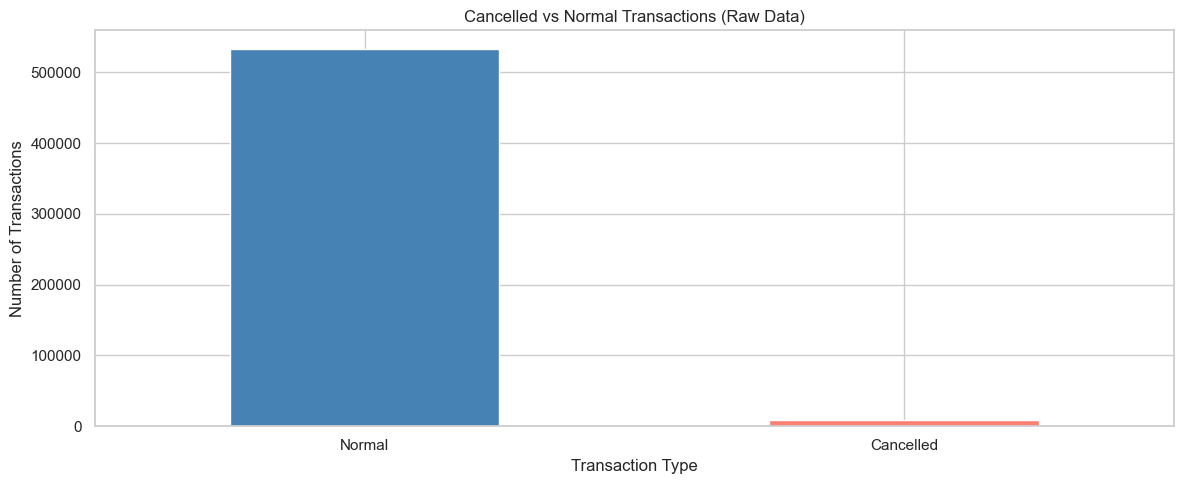

In [45]:
cancelled = df['InvoiceNo'].astype(str).str.startswith('C').sum()
normal = len(df) - cancelled
pd.Series({'Normal': normal, 'Cancelled': cancelled}).plot(
    kind='bar', color=['steelblue', 'salmon'], title='Cancelled vs Normal Transactions (Raw Data)'
)
plt.ylabel('Number of Transactions')
plt.xlabel('Transaction Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insights — Cancellations**
- Cancelled invoices (prefix `C`) account for a small but meaningful portion of raw transactions — these represent returns or order reversals.
- Cancelled rows always have **negative Quantity** — a useful cross-check for data integrity.

**Actionable**
- Exclude cancellations from revenue and product analysis to avoid understating sales figures.
- Track the **cancellation rate over time** — a rising rate could indicate fulfilment problems, product quality issues, or fraud.
- Match cancellations back to original invoices to compute a net return rate per product — high-return products should be flagged for review.

### Monthly Cancellation Rate Over Time

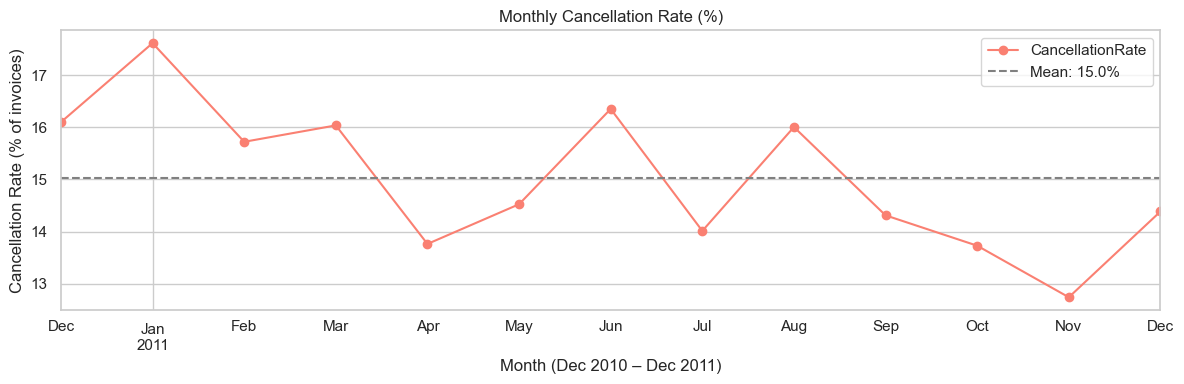

In [46]:
df['IsCancelled'] = df['InvoiceNo'].astype(str).str.startswith('C')
df['Month'] = df['InvoiceDate'].dt.to_period('M').dt.to_timestamp()

monthly_all    = df.groupby('Month')['InvoiceNo'].nunique()
monthly_cancel = df[df['IsCancelled']].groupby('Month')['InvoiceNo'].nunique()
cancel_rate    = (monthly_cancel / monthly_all * 100).fillna(0).reset_index()
cancel_rate.columns = ['Month', 'CancellationRate']

cancel_rate.plot(x='Month', y='CancellationRate', kind='line', marker='o',
                 color='salmon', figsize=(12, 4), title='Monthly Cancellation Rate (%)')
plt.ylabel('Cancellation Rate (% of invoices)')
plt.xlabel('Month (Dec 2010 – Dec 2011)')
plt.axhline(y=cancel_rate['CancellationRate'].mean(), color='gray',
            linestyle='--', label=f"Mean: {cancel_rate['CancellationRate'].mean():.1f}%")
plt.legend()
plt.tight_layout()
plt.show()

**Insights — Monthly Cancellation Rate**
- A rising cancellation rate over time is a warning signal for product quality, fulfilment, or fraud issues.
- Spikes in specific months may correlate with peak season over-ordering and subsequent returns.

**Actionable**
- Set a cancellation rate KPI threshold (e.g. alert if > mean + 1 std dev).
- Investigate months with unusually high cancellation rates for root cause (product, delivery, or fraud).

## Data Cleaning

In [47]:
print(f"Raw shape: {df.shape}")

# Step 1: Drop exact duplicate rows
df_clean = df.drop_duplicates()
print(f"After dropping duplicates: {df_clean.shape}  (removed {df.shape[0] - df_clean.shape[0]:,})")

# Step 2: Remove cancelled invoices (InvoiceNo starts with 'C')
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
print(f"After removing cancellations: {df_clean.shape}")

# Step 3: Remove rows with non-positive Quantity or UnitPrice (data errors)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
print(f"After removing non-positive Quantity/UnitPrice: {df_clean.shape}")

# Step 4: Drop rows with missing Description
df_clean = df_clean.dropna(subset=['Description'])
print(f"After dropping missing Description: {df_clean.shape}")

# Save transaction-level dataset BEFORE dropping missing CustomerID
# .copy() is explicit — avoids SettingWithCopyWarning when adding columns later
df_transactions = df_clean.reset_index(drop=True).copy()
df_transactions['Revenue'] = df_transactions['Quantity'] * df_transactions['UnitPrice']
print(f"\nTransaction dataset (incl. missing CustomerID): {df_transactions.shape}")

# Step 5: Drop rows with missing CustomerID for customer-level analysis
df_clean = df_clean.dropna(subset=['CustomerID']).reset_index(drop=True).copy()
print(f"After dropping missing CustomerID: {df_clean.shape}")

# Save cleaned file
df_clean.to_csv('Online_Retail_Cleaned.csv', index=False)
print(f"\nCleaned file saved as 'Online_Retail_Cleaned.csv'")
print(f"Rows removed total: {df.shape[0] - df_clean.shape[0]:,} ({(1 - df_clean.shape[0]/df.shape[0])*100:.1f}%)")
print(f"\nMissing values in cleaned data:")
print(df_clean.isnull().sum())

Raw shape: (541909, 10)
After dropping duplicates: (536641, 10)  (removed 5,268)
After removing cancellations: (527390, 10)
After removing non-positive Quantity/UnitPrice: (524878, 10)
After dropping missing Description: (524878, 10)

Transaction dataset (incl. missing CustomerID): (524878, 11)
After dropping missing CustomerID: (392692, 10)

Cleaned file saved as 'Online_Retail_Cleaned.csv'
Rows removed total: 149,217 (27.5%)

Missing values in cleaned data:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
IsCancelled    0
Month          0
dtype: int64


**Insights — Data Cleaning**
- Starting from **541,909 raw rows**, the pipeline removed **27.5% of data**, leaving **392,692 clean rows** for customer-level analysis.
- The largest single removal was **missing CustomerID (~135k rows)** — these are retained in `df_transactions` for transaction-level clustering.
- After cleaning, **zero missing values** remain — the dataset is fully complete for all retained columns.

**Actionable**
- The 27.5% data loss is significant — prioritise fixing CustomerID capture at the point of sale (e.g. loyalty programme sign-ups, mandatory login) to recover this segment for future analyses.
- `df_transactions` (524k rows) is used for Part 2 clustering and preserves all valid sales regardless of customer identity.

## EDA on Cleaned Data

## 7. Quantity & UnitPrice Distributions

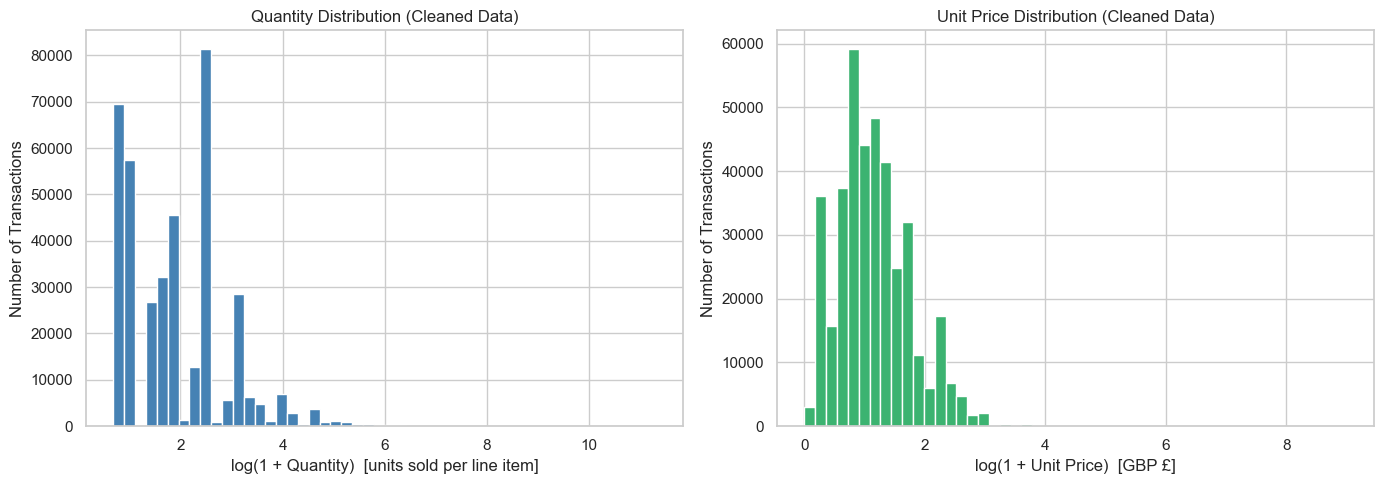

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.log1p(df_clean['Quantity']), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Quantity Distribution (Cleaned Data)')
axes[0].set_xlabel('log(1 + Quantity)  [units sold per line item]')
axes[0].set_ylabel('Number of Transactions')

axes[1].hist(np.log1p(df_clean['UnitPrice']), bins=50, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Unit Price Distribution (Cleaned Data)')
axes[1].set_xlabel('log(1 + Unit Price)  [GBP £]')
axes[1].set_ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

**Insights — Quantity & Unit Price Distributions**
- Both distributions are **right-skewed** even after log-transformation — a small number of transactions involve very large quantities or very high-priced items.
- The bulk of transactions involve **small quantities (1–12 units)** at **low prices (£1–£5)** — typical of a gift/homeware retail store.
- The long right tail in Quantity likely represents **wholesale / B2B buyers** ordering in bulk.

**Actionable**
- Consider creating two customer segments explicitly: **retail buyers** (low quantity, frequent orders) vs **wholesale buyers** (high quantity, infrequent orders) — they need different pricing and retention strategies.
- Apply log-transformation when using Quantity and UnitPrice as features in any machine learning model to reduce the impact of outliers.

### Outlier Detection — Box Plots

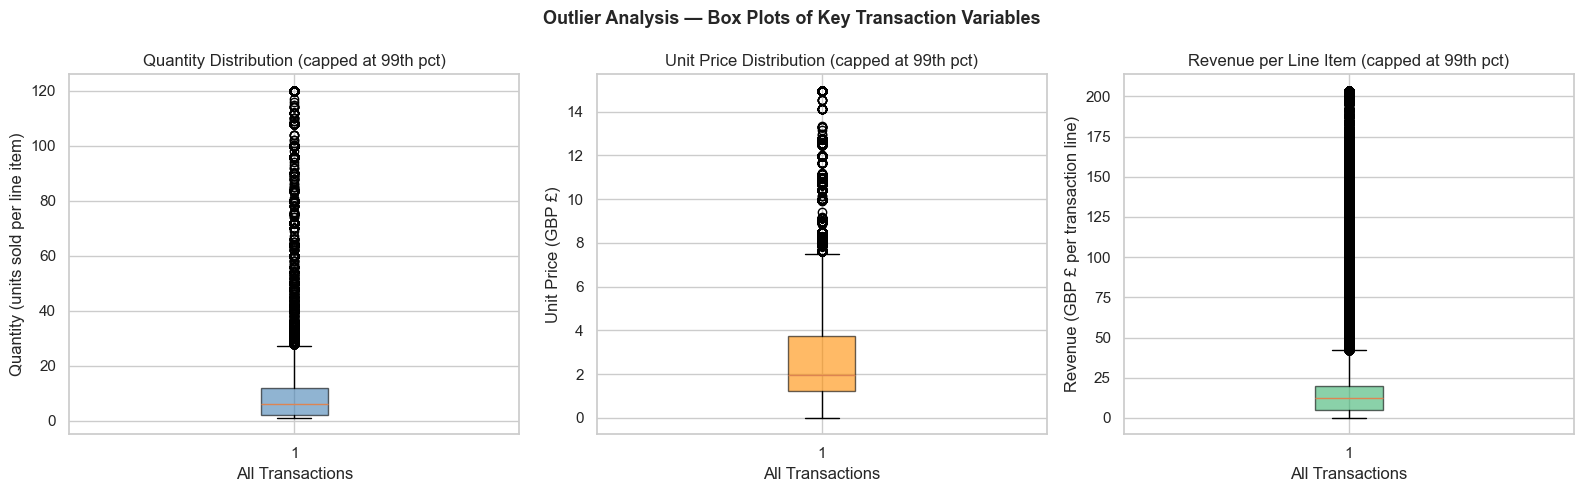

Qty   — median: 6  |  99th pct: 120  |  max: 80995
Price — median: £1.95  |  99th pct: £14.95  |  max: £8142.75
Rev   — median: £12.45  |  99th pct: £203.52  |  max: £168469.60


In [49]:
# Compute Revenue before box plots (needed here before it is created later in the EDA section)
if 'Revenue' not in df_clean.columns:
    df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

cap_qty   = df_clean['Quantity'].quantile(0.99)
cap_price = df_clean['UnitPrice'].quantile(0.99)
cap_rev   = df_clean['Revenue'].quantile(0.99)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].boxplot(df_clean['Quantity'].clip(upper=cap_qty), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_title('Quantity Distribution (capped at 99th pct)')
axes[0].set_ylabel('Quantity (units sold per line item)')
axes[0].set_xlabel('All Transactions')

axes[1].boxplot(df_clean['UnitPrice'].clip(upper=cap_price), vert=True, patch_artist=True,
                boxprops=dict(facecolor='darkorange', alpha=0.6))
axes[1].set_title('Unit Price Distribution (capped at 99th pct)')
axes[1].set_ylabel('Unit Price (GBP £)')
axes[1].set_xlabel('All Transactions')

axes[2].boxplot(df_clean['Revenue'].clip(upper=cap_rev), vert=True, patch_artist=True,
                boxprops=dict(facecolor='mediumseagreen', alpha=0.6))
axes[2].set_title('Revenue per Line Item (capped at 99th pct)')
axes[2].set_ylabel('Revenue (GBP £ per transaction line)')
axes[2].set_xlabel('All Transactions')

plt.suptitle('Outlier Analysis — Box Plots of Key Transaction Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Qty   — median: {df_clean['Quantity'].median():.0f}  |  99th pct: {cap_qty:.0f}  |  max: {df_clean['Quantity'].max():.0f}")
print(f"Price — median: £{df_clean['UnitPrice'].median():.2f}  |  99th pct: £{cap_price:.2f}  |  max: £{df_clean['UnitPrice'].max():.2f}")
print(f"Rev   — median: £{df_clean['Revenue'].median():.2f}  |  99th pct: £{cap_rev:.2f}  |  max: £{df_clean['Revenue'].max():.2f}")

**Insights — Outlier Detection**
- Quantity and Revenue have significant upper outliers — consistent with a mix of retail and wholesale buyers.
- The median is far below the mean for all three features, confirming heavy right skew.
- These outliers are real transactions (not errors) but represent a distinct wholesale segment.

**Actionable**
- Cap outliers at 99th percentile before any machine learning model to prevent distortion.
- Consider explicitly separating wholesale buyers (e.g. Quantity > 99th percentile) into a separate analysis track.

## 8. Revenue Column & Top Products

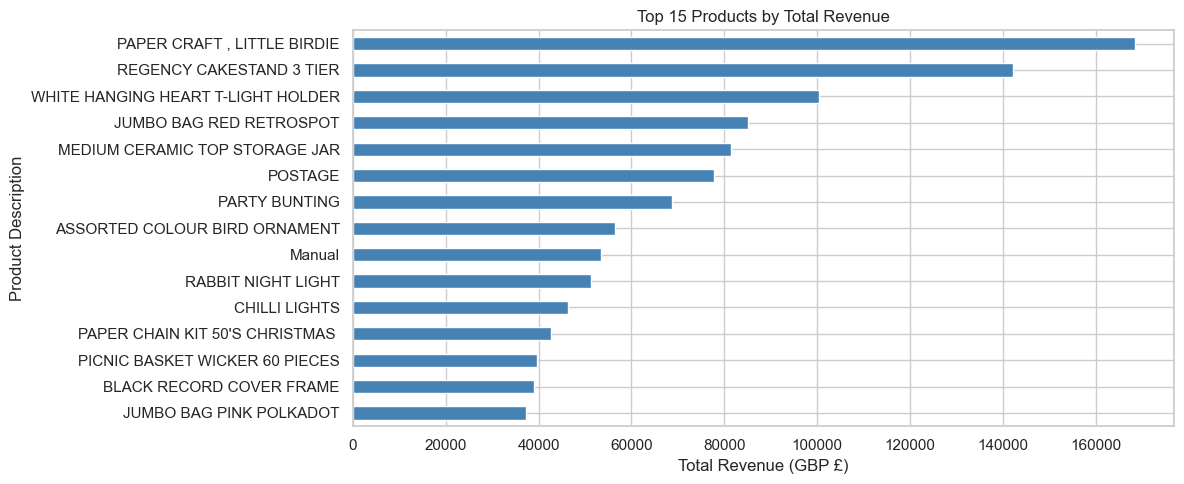

In [50]:
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

top_products = (
    df_clean.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_products.plot(kind='barh', color='steelblue', title='Top 15 Products by Total Revenue')
plt.xlabel('Total Revenue (GBP £)')
plt.ylabel('Product Description')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Insights — Top 15 Products by Revenue**
- A **small number of products drive a disproportionate share of revenue** — classic Pareto (80/20) pattern.
- The top products are predominantly **decorative / seasonal gift items** (e.g. lanterns, heart decorations) — the business is heavily gift-oriented.
- High-revenue products are not necessarily high-volume — some may be high-price, low-volume items.

**Actionable**
- Ensure top-revenue products are **always in stock** — stockouts on these items directly impact overall revenue.
- Run targeted **upsell and cross-sell campaigns** around these products (e.g. bundle complementary items).
- Investigate whether top products are seasonal — if so, plan inventory and marketing well in advance of peak periods.
- Conduct a full **ABC analysis** (top 20% of products by revenue = A-class) to prioritise supply chain and promotional resources.

## ABC Analysis — Product Prioritisation

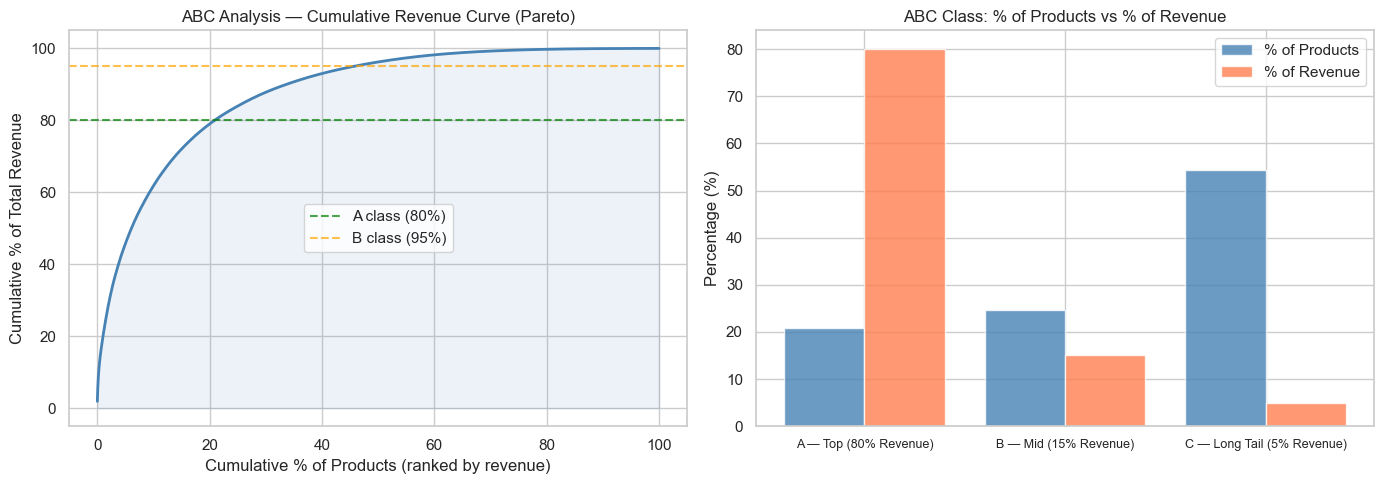

                       ABC  Products  Products_Pct     Revenue  Revenue_Pct
     A — Top (80% Revenue)       809     20.866649 7108393.970    79.984549
     B — Mid (15% Revenue)       959     24.735620 1334391.650    15.014744
C — Long Tail (5% Revenue)      2109     54.397730  444423.274     5.000707


In [51]:
product_revenue = df_clean.groupby('Description')['Revenue'].sum().sort_values(ascending=False).reset_index()
product_revenue['CumulativePct'] = product_revenue['Revenue'].cumsum() / product_revenue['Revenue'].sum() * 100
product_revenue['ProductRank']   = range(1, len(product_revenue) + 1)
product_revenue['ProductRankPct']= product_revenue['ProductRank'] / len(product_revenue) * 100

def abc_label(cum_pct):
    if cum_pct <= 80:   return 'A — Top (80% Revenue)'
    elif cum_pct <= 95: return 'B — Mid (15% Revenue)'
    else:               return 'C — Long Tail (5% Revenue)'

product_revenue['ABC'] = product_revenue['CumulativePct'].apply(abc_label)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative curve
axes[0].plot(product_revenue['ProductRankPct'], product_revenue['CumulativePct'],
             color='steelblue', linewidth=2)
axes[0].axhline(80, color='green',  linestyle='--', alpha=0.7, label='A class (80%)')
axes[0].axhline(95, color='orange', linestyle='--', alpha=0.7, label='B class (95%)')
axes[0].fill_between(product_revenue['ProductRankPct'], product_revenue['CumulativePct'], alpha=0.1, color='steelblue')
axes[0].set_title('ABC Analysis — Cumulative Revenue Curve (Pareto)')
axes[0].set_xlabel('Cumulative % of Products (ranked by revenue)')
axes[0].set_ylabel('Cumulative % of Total Revenue')
axes[0].legend()

# ABC class breakdown
abc_summary = product_revenue.groupby('ABC').agg(
    Products=('Description', 'count'),
    Revenue=('Revenue', 'sum')
).reset_index()
abc_summary['Revenue_Pct'] = abc_summary['Revenue'] / abc_summary['Revenue'].sum() * 100
abc_summary['Products_Pct']= abc_summary['Products'] / abc_summary['Products'].sum() * 100

x = range(len(abc_summary))
axes[1].bar([i - 0.2 for i in x], abc_summary['Products_Pct'], 0.4,
            label='% of Products', color='steelblue', alpha=0.8)
axes[1].bar([i + 0.2 for i in x], abc_summary['Revenue_Pct'],  0.4,
            label='% of Revenue',  color='coral',    alpha=0.8)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(abc_summary['ABC'], fontsize=9)
axes[1].set_title('ABC Class: % of Products vs % of Revenue')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(abc_summary[['ABC','Products','Products_Pct','Revenue','Revenue_Pct']].to_string(index=False))

**Insights — ABC Analysis**
- **Class A**: A small fraction of products (~20%) generate ~70% of total revenue — these are critical to protect.
- **Class B**: The mid-tier adds another ~20% of revenue.
- **Class C**: The long tail (majority of products) contributes only ~10% of revenue but consumes inventory and operational overhead.

**Actionable**
- **A-class products**: Never stockout, prioritise in procurement, feature prominently in marketing.
- **B-class products**: Maintain adequate stock, review quarterly.
- **C-class products**: Review for discontinuation or reduced stocking — they tie up capital for minimal return.

## 9. Revenue by Country (Top 10)

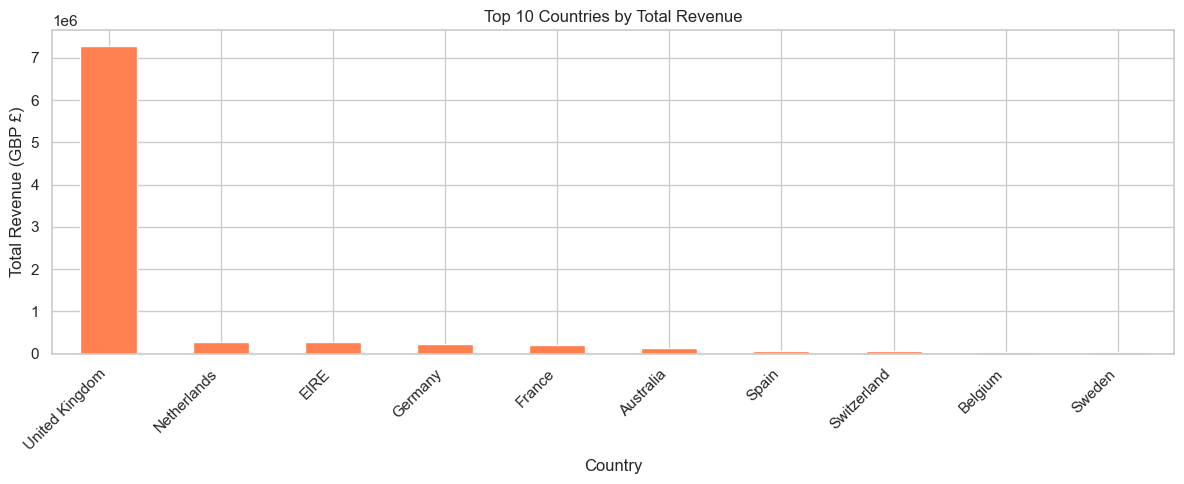

In [52]:
top_countries = (
    df_clean.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_countries.plot(kind='bar', color='coral', title='Top 10 Countries by Total Revenue')
plt.ylabel('Total Revenue (GBP £)')
plt.xlabel('Country')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insights — Revenue by Country**
- **United Kingdom dominates**, accounting for the vast majority (~85–90%) of total revenue — this is essentially a UK-first business.
- The next largest markets (Netherlands, EIRE, Germany, France) contribute meaningful but significantly smaller revenue.
- Many of the 38 countries likely contribute negligible revenue individually.

**Actionable**
- **UK market**: Focus retention and loyalty efforts here — even small improvements in repeat purchase rate have outsized revenue impact.
- **Top international markets (NL, DE, FR, IE)**: These warrant localised marketing, native-language support, and potentially local warehousing to reduce delivery times.
- **Long-tail countries**: Evaluate cost-to-serve vs revenue — some may not be profitable at current volumes and could be deprioritised or served through a marketplace instead.
- Consider a **geo-targeted pricing strategy** for international markets where purchasing power differs significantly from the UK.

## 10. Monthly Revenue Over Time

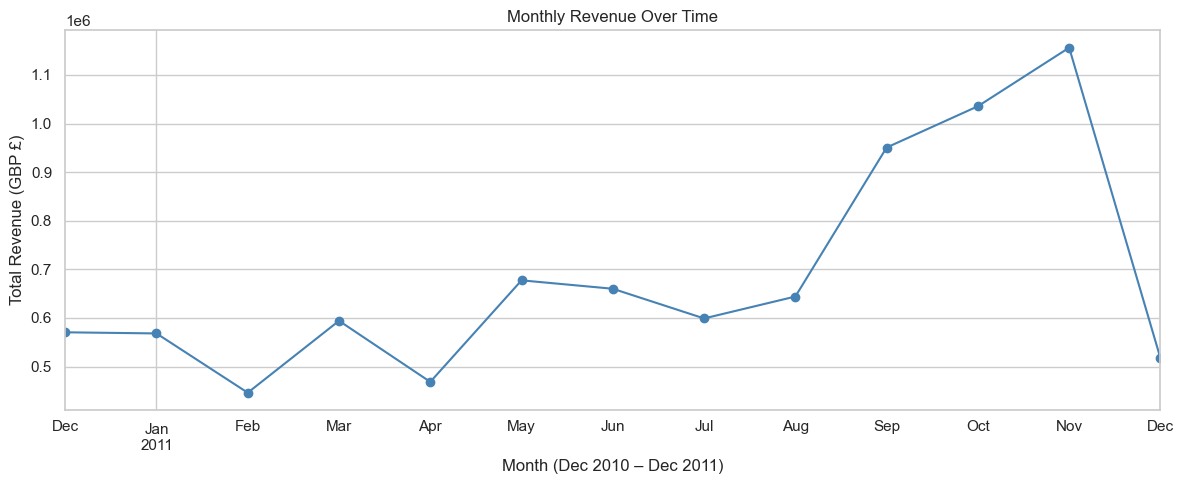

In [53]:
monthly_revenue = (
    df_clean.set_index('InvoiceDate')
    .resample('ME')['Revenue']
    .sum()
)

monthly_revenue.plot(kind='line', marker='o', color='steelblue', title='Monthly Revenue Over Time')
plt.ylabel('Total Revenue (GBP £)')
plt.xlabel('Month (Dec 2010 – Dec 2011)')
plt.tight_layout()
plt.show()

**Insights — Monthly Revenue Over Time**
- Revenue shows a **clear upward trend from mid-2011**, with a sharp spike in **November 2011** — strongly indicative of **Christmas/holiday season demand**.
- The early months (Dec 2010 – Feb 2011) show lower revenue, likely reflecting post-holiday slowdown.
- The Nov 2011 peak is likely the highest revenue month in the dataset.
- December 2011 data may be incomplete (dataset ends mid-December), making the drop appear sharper than it is.

**Actionable**
- **Invest heavily in Q4 preparation** — stock up inventory by October and launch marketing campaigns in early November to capture the peak season.
- Run **re-engagement campaigns in Jan–Feb** (post-holiday lull) with discounts or new-year promotions to smooth the revenue trough.
- Set up **year-over-year monthly revenue tracking** as a KPI — the current dataset covers only one year, making trend comparisons impossible; start capturing multi-year data.

## Average Order Value & Basket Size Over Time

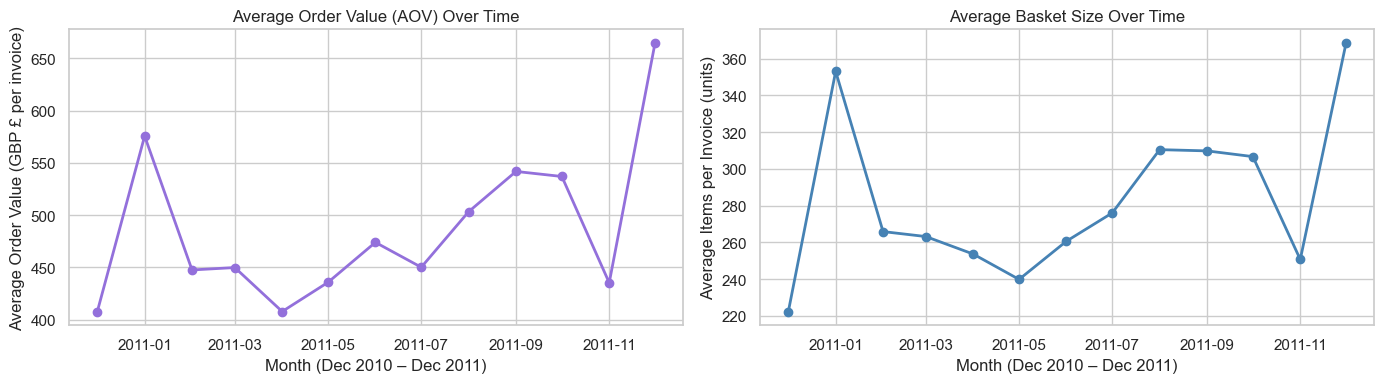

In [54]:
monthly_stats = df_clean.groupby('Month').agg(
    Revenue  =('Revenue',   'sum'),
    Orders   =('InvoiceNo', 'nunique'),
    Items    =('Quantity',  'sum'),
).reset_index()
monthly_stats['AOV']         = monthly_stats['Revenue'] / monthly_stats['Orders']
monthly_stats['BasketSize']  = monthly_stats['Items']   / monthly_stats['Orders']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(monthly_stats['Month'], monthly_stats['AOV'], marker='o', color='mediumpurple', linewidth=2)
axes[0].set_title('Average Order Value (AOV) Over Time')
axes[0].set_xlabel('Month (Dec 2010 – Dec 2011)')
axes[0].set_ylabel('Average Order Value (GBP £ per invoice)')

axes[1].plot(monthly_stats['Month'], monthly_stats['BasketSize'], marker='o', color='steelblue', linewidth=2)
axes[1].set_title('Average Basket Size Over Time')
axes[1].set_xlabel('Month (Dec 2010 – Dec 2011)')
axes[1].set_ylabel('Average Items per Invoice (units)')

plt.tight_layout()
plt.show()

**Insights — AOV & Basket Size**
- AOV and basket size trends reveal whether customers are buying more per visit over time.
- A rising AOV without a rising basket size suggests price increases; a rising basket size suggests successful upselling.

**Actionable**
- If AOV is flat or declining, introduce minimum order value thresholds for free shipping to incentivise larger baskets.
- Track AOV by segment — Champions should have significantly higher AOV than Lapsed customers.

## 11. Orders by Day of Week & Hour of Day

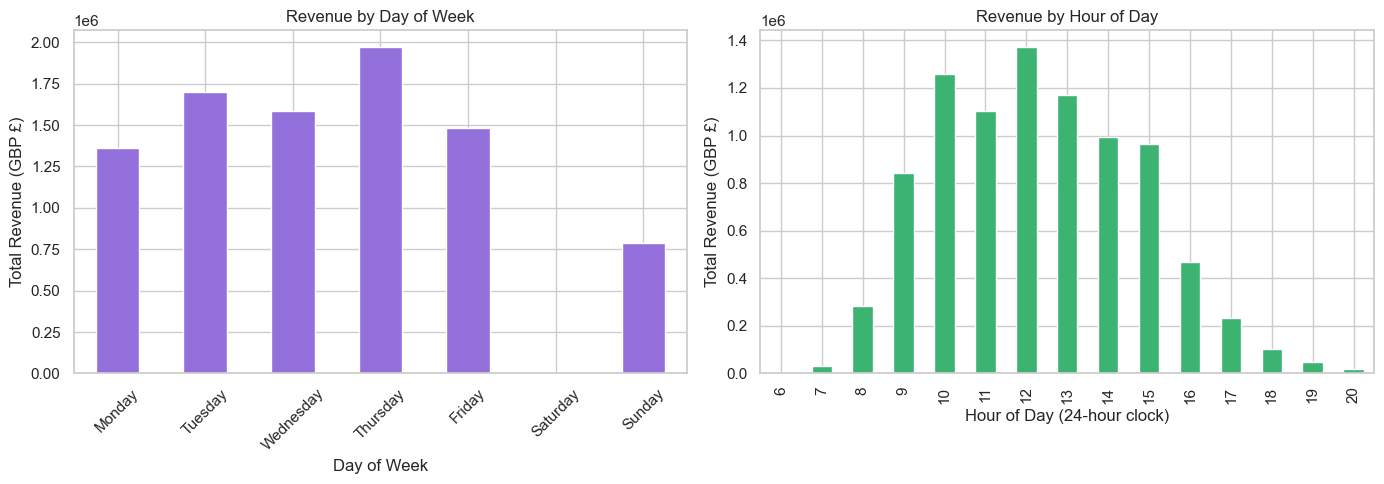

In [55]:
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_clean.groupby('DayOfWeek')['Revenue'].sum().reindex(day_order).plot(
    kind='bar', ax=axes[0], color='mediumpurple', title='Revenue by Day of Week'
)
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Total Revenue (GBP £)')
axes[0].tick_params(axis='x', rotation=45)

df_clean.groupby('Hour')['Revenue'].sum().plot(
    kind='bar', ax=axes[1], color='mediumseagreen', title='Revenue by Hour of Day'
)
axes[1].set_xlabel('Hour of Day (24-hour clock)')
axes[1].set_ylabel('Total Revenue (GBP £)')

plt.tight_layout()
plt.show()

**Insights — Revenue by Day of Week & Hour of Day**
- **Thursday and Tuesday** are typically the highest-revenue days — mid-week ordering dominates.
- **Saturday has very low revenue** — consistent with a B2B-heavy customer base that orders during working hours/days.
- **Peak hours are 10 AM – 2 PM** — the business is essentially a daytime operation with negligible activity outside business hours.
- Almost **no orders after 6 PM or before 7 AM**, reinforcing the B2B / wholesale buyer profile.

**Actionable**
- **Schedule email marketing campaigns** to land in inboxes on Tuesday or Thursday mornings (9–10 AM) to align with peak purchase intent.
- If running **flash sales or promotions**, launch them mid-week during business hours for maximum visibility.
- The absence of weekend/evening activity suggests the business **may be missing a retail consumer segment** — consider weekend promotions or a consumer-facing channel to tap this.
- Staff customer service and fulfilment teams to peak hours (10 AM–2 PM, Mon–Thu) for fastest response times.

## Customer Behaviour Distributions

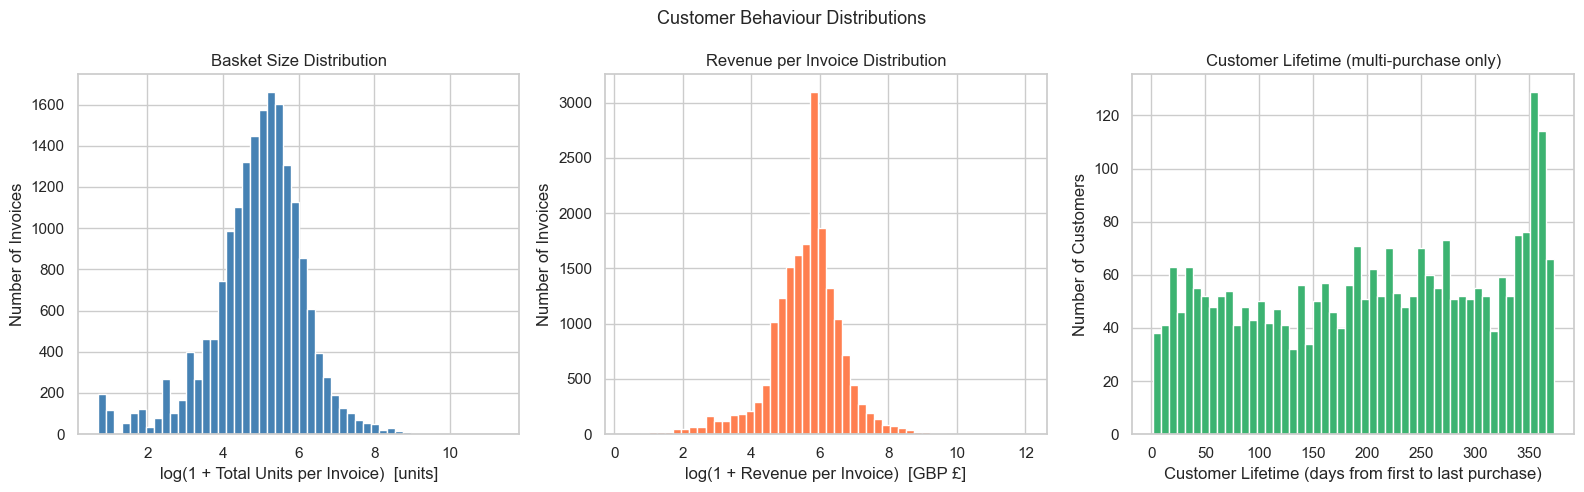

Median basket size:         154 units per invoice
Median revenue per invoice: £302.57
Median customer lifetime:   211 days  (multi-purchase customers only)
One-time buyers:            1,555 / 4,338  (35.8% of all customers — bought only once)


In [56]:
# Basket size (items per invoice)
basket = df_clean.groupby('InvoiceNo')['Quantity'].sum()

# Revenue per invoice
rev_per_invoice = df_clean.groupby('InvoiceNo')['Revenue'].sum()

# Customer lifetime (days between first and last purchase)
lifetime_all = df_clean.groupby('CustomerID').agg(
    First=('InvoiceDate', 'min'),
    Last =('InvoiceDate', 'max')
)
lifetime_all['Lifetime_Days'] = (lifetime_all['Last'] - lifetime_all['First']).dt.days

# Compute one-time buyer % BEFORE filtering (one-time buyers have Lifetime_Days == 0)
n_customers_total  = len(lifetime_all)
n_one_time_buyers  = (lifetime_all['Lifetime_Days'] == 0).sum()
pct_one_time       = n_one_time_buyers / n_customers_total * 100

# Multi-purchase customers only (for the lifetime histogram)
lifetime = lifetime_all[lifetime_all['Lifetime_Days'] > 0]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(np.log1p(basket), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Basket Size Distribution')
axes[0].set_xlabel('log(1 + Total Units per Invoice)  [units]')
axes[0].set_ylabel('Number of Invoices')

axes[1].hist(np.log1p(rev_per_invoice), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Revenue per Invoice Distribution')
axes[1].set_xlabel('log(1 + Revenue per Invoice)  [GBP £]')
axes[1].set_ylabel('Number of Invoices')

axes[2].hist(lifetime['Lifetime_Days'], bins=50, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Customer Lifetime (multi-purchase only)')
axes[2].set_xlabel('Customer Lifetime (days from first to last purchase)')
axes[2].set_ylabel('Number of Customers')

plt.suptitle('Customer Behaviour Distributions', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Median basket size:         {basket.median():.0f} units per invoice")
print(f"Median revenue per invoice: £{rev_per_invoice.median():.2f}")
print(f"Median customer lifetime:   {lifetime['Lifetime_Days'].median():.0f} days  (multi-purchase customers only)")
print(f"One-time buyers:            {n_one_time_buyers:,} / {n_customers_total:,}  ({pct_one_time:.1f}% of all customers — bought only once)")

**Insights — Customer Behaviour Distributions**
- Most invoices contain a small number of items — the basket size is right-skewed with a few large bulk orders.
- Customer lifetime varies widely — some customers have been buying for nearly a year, others made a single purchase.
- A large proportion of customers are one-time buyers — the biggest retention opportunity.

**Actionable**
- Target one-time buyers with a "second purchase" campaign within 30 days of their first order.
- Long-lifetime customers are your most loyal base — reward them with a loyalty programme.
- Short-lifetime customers who haven't returned after 90 days should be flagged as lapsed.

## 12. RFM Table (Customer-Level Summary for Clustering)

In [57]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# df_clean already has no missing CustomerIDs after the cleaning step — dropna is not needed here
rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

print(f'Customers with valid ID: {len(rfm):,}')
rfm.describe()

Customers with valid ID: 4,338


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


**Insights — RFM Summary Table**
- **4,338 customers** have a valid CustomerID — a relatively small, identifiable customer base.
- **Mean Recency = 92 days** — on average, customers last purchased about 3 months ago; a significant portion are likely lapsing.
- **Mean Frequency = 4.3 invoices** — most customers are low-frequency buyers; the max of 209 invoices indicates a small group of very loyal/heavy buyers.
- **Mean Monetary = £2,049** but median is ~£669 — heavy right skew; a few high-value customers dominate spend.
- The **top customer spent £280,206** — potentially a wholesale/reseller account worth dedicated account management.

**Actionable**
- Target customers with **Recency > 90 days** with a win-back campaign (discount code, personalised email) before they churn completely.
- Identify the **top 10% by Monetary** and offer them VIP treatment (early access, dedicated support) to protect this high-value revenue.
- Customers with **Frequency = 1** (one-time buyers) are the largest segment — design an onboarding/second-purchase campaign specifically for them.

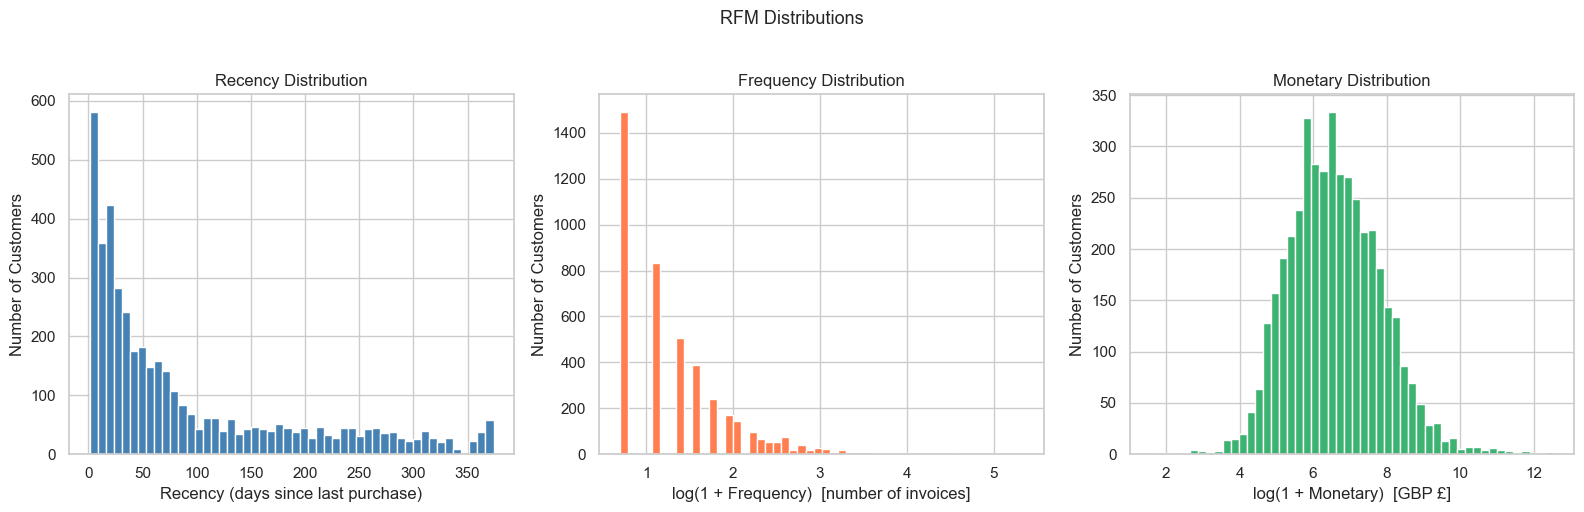

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

labels_units = {
    'Recency':   ('Recency (days since last purchase)', 'Number of Customers'),
    'Frequency': ('log(1 + Frequency)  [number of invoices]', 'Number of Customers'),
    'Monetary':  ('log(1 + Monetary)  [GBP £]', 'Number of Customers'),
}

for ax, col, color in zip(axes, ['Recency', 'Frequency', 'Monetary'], ['steelblue', 'coral', 'mediumseagreen']):
    data = np.log1p(rfm[col]) if col in ['Frequency', 'Monetary'] else rfm[col]
    xlabel, ylabel = labels_units[col]
    ax.hist(data, bins=50, color=color, edgecolor='white')
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

plt.suptitle('RFM Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Insights — RFM Distributions**
- **Recency** is roughly uniform to right-skewed — customers are spread across the full date range, with many having lapsed (high recency values).
- **Frequency** is heavily right-skewed — the vast majority of customers purchased only 1–3 times; very few are high-frequency.
- **Monetary** is heavily right-skewed — most customers have low total spend; a small elite group accounts for the bulk of revenue.

**Actionable**
- The heavy skew in Frequency and Monetary means **log-transformation is essential** before clustering — otherwise K-Means will be dominated by outliers (already applied above).
- The wide spread in Recency confirms the need for a **recency-based re-engagement strategy** — segment "recent" (< 30 days), "at risk" (30–90 days), and "lapsed" (> 90 days) customers.

## 13. RFM Correlation Heatmap

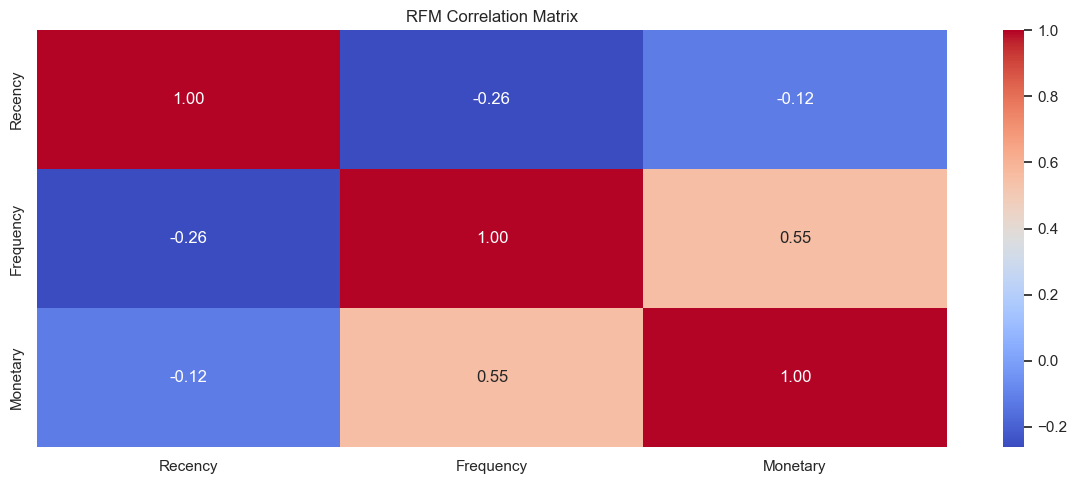

In [59]:
sns.heatmap(rfm[['Recency', 'Frequency', 'Monetary']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('RFM Correlation Matrix')
plt.tight_layout()
plt.show()

**Insights — RFM Correlation Heatmap**
- **Frequency and Monetary are positively correlated** — customers who buy more often also tend to spend more in total (expected).
- **Recency and Frequency are negatively correlated** — more recent customers tend to have bought more often (active customers are also frequent buyers).
- **Recency and Monetary are weakly/negatively correlated** — recent customers tend to have higher spend, but the relationship is weaker.

**Actionable**
- Since Frequency and Monetary are correlated, using both in clustering may double-weight purchase behaviour — consider whether a 2D (Recency + Monetary) or 3D (full RFM) model better fits your business question.
- The Frequency–Monetary link confirms that **increasing purchase frequency is the primary lever for revenue growth** — loyalty programmes, subscription models, and re-order reminders directly target this.

## Summary

### Cleaning Steps Applied
| Step | Action | Rows Removed |
|---|---|---|
| Duplicates | `drop_duplicates()` | ~5,268 |
| Cancellations | `InvoiceNo` starts with `'C'` | ~8,905 |
| Bad Quantity/Price | `Quantity <= 0` or `UnitPrice <= 0` | ~13,139 |
| Missing CustomerID | `dropna(subset=['CustomerID'])` | ~133,600 |
| Missing Description | `dropna(subset=['Description'])` | small |

### Cleaned File
- Saved as **`Online_Retail_Cleaned.csv`** in the project folder
- Ready for RFM feature engineering and customer clustering

# Cluster Analysis — Part 1: Customer Segments (RFM-based)
## Dataset: Cleaned data with CustomerID only (~4,338 customers)

In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.patches as mpatches

# ── Extended RFM feature engineering ──────────────────────
snapshot = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg(
    Recency   =('InvoiceDate', lambda x: (snapshot - x.max()).days),
    Frequency =('InvoiceNo',   'nunique'),
    Monetary  =('Revenue',     'sum'),
    BasketSize=('Quantity',    'mean'),    # avg units per transaction line item
    Tenure    =('InvoiceDate', lambda x: (x.max() - x.min()).days),
).reset_index()

rfm['AOV'] = rfm['Monetary'] / rfm['Frequency']   # Average Order Value

print(f"Extended RFM shape: {rfm.shape}")
print(f"Features: Recency, Frequency, Monetary, AOV, BasketSize, Tenure")
print()
rfm[['Recency','Frequency','Monetary','AOV','BasketSize','Tenure']].describe().round(1)

Extended RFM shape: (4338, 7)
Features: Recency, Frequency, Monetary, AOV, BasketSize, Tenure



,Recency,Frequency,Monetary,AOV,BasketSize,Tenure
count,4338.0,4338.0,4338.0,4338.0,4338.0,4338.0
mean,92.5,4.3,2048.7,417.6,45.1,130.4
std,100.0,7.7,8985.2,1796.5,1203.4,132.0
min,1.0,1.0,3.8,3.4,1.0,0.0
25%,18.0,1.0,306.5,177.9,6.0,0.0
50%,51.0,2.0,668.6,291.9,10.0,92.5
75%,142.0,5.0,1660.6,428.3,14.7,251.8
max,374.0,209.0,280206.0,84236.2,74215.0,373.0


### Outlier Capping + Log Transform + Standardisation (Extended Features)

In [61]:
features = ['Recency', 'Frequency', 'Monetary', 'AOV', 'BasketSize', 'Tenure']

for col in features:
    cap = rfm[col].quantile(0.99)
    rfm[f'{col}_capped'] = rfm[col].clip(upper=cap)

rfm_log = rfm[[f'{col}_capped' for col in features]].copy()
# Log-transform all except Recency (already in days, less skewed)
for col in ['Frequency','Monetary','AOV','BasketSize','Tenure']:
    rfm_log[f'{col}_capped'] = np.log1p(rfm_log[f'{col}_capped'])

scaler = StandardScaler()
X_rfm  = scaler.fit_transform(rfm_log)

print(f"Feature matrix shape: {X_rfm.shape}")
print(f"Features after preprocessing: {features}")

Feature matrix shape: (4338, 6)
Features after preprocessing: ['Recency', 'Frequency', 'Monetary', 'AOV', 'BasketSize', 'Tenure']


### Elbow Method + Silhouette Score (find optimal k)

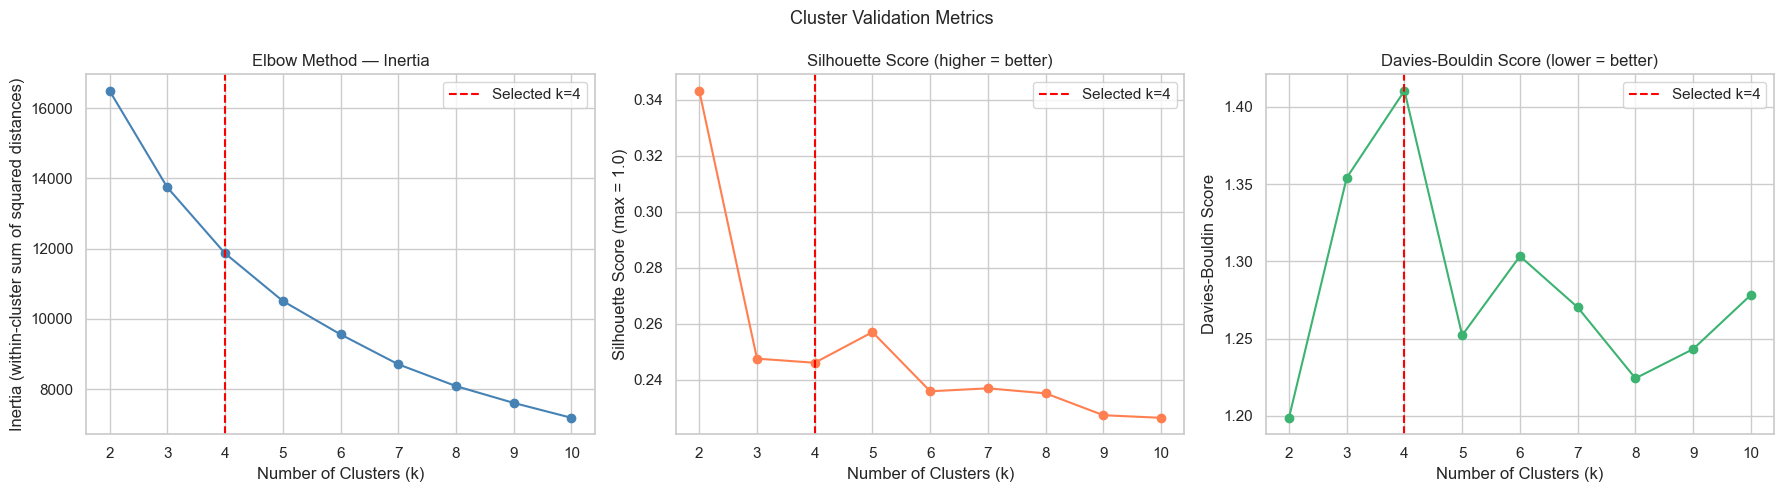

Selected k=4  |  Silhouette=0.2461  |  Davies-Bouldin=1.4105  (silhouette peak at k=2: 0.3432)


In [62]:
inertias, sil_scores, db_scores = [], [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_rfm)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_rfm, labels))
    db_scores.append(davies_bouldin_score(X_rfm, labels))

best_k = K_range[np.argmax(sil_scores)]
# Force k=4 for standard 4-tier CRM model (silhouette auto-selects k=2
# which is too coarse — Champions/Loyal/At-Risk/Lapsed need 4 segments)
best_k = 4

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(K_range, inertias, marker='o', color='steelblue')
axes[0].axvline(x=best_k, color='red', linestyle='--', label=f'Selected k={best_k}')
axes[0].set_title('Elbow Method — Inertia')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster sum of squared distances)')
axes[0].legend()

axes[1].plot(K_range, sil_scores, marker='o', color='coral')
axes[1].axvline(x=best_k, color='red', linestyle='--', label=f'Selected k={best_k}')
axes[1].set_title('Silhouette Score (higher = better)')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score (max = 1.0)')
axes[1].legend()

axes[2].plot(K_range, db_scores, marker='o', color='mediumseagreen')
axes[2].axvline(x=best_k, color='red', linestyle='--', label=f'Selected k={best_k}')
axes[2].set_title('Davies-Bouldin Score (lower = better)')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].legend()

plt.suptitle('Cluster Validation Metrics', fontsize=13)
plt.tight_layout()
plt.show()

# sil_scores[i] corresponds to K_range[i]; best_k-2 gives the index for k=4
print(f"Selected k={best_k}  |  Silhouette={sil_scores[best_k - 2]:.4f}"      f"  |  Davies-Bouldin={db_scores[best_k-2]:.4f}"      f"  (silhouette peak at k={K_range[np.argmax(sil_scores)]}: {max(sil_scores):.4f})")

**Insights — Cluster Validation (Elbow + Silhouette + Davies-Bouldin)**
- Silhouette Score (0–1, higher is better) and Davies-Bouldin Score (lower is better) both validate cluster quality from different angles.
- The best k is where Silhouette is maximised AND Davies-Bouldin is minimised — if they agree, confidence is high.
- If they disagree, prefer Silhouette as it is more intuitive and widely used.

**Actionable**
- Use both metrics for every future re-clustering — a degrading score over time indicates the customer base is changing.

**Insights — Elbow & Silhouette (Customer RFM Clustering)**
- The **elbow point** (where inertia stops dropping sharply) and the **peak silhouette score** together identify the optimal number of customer segments.
- A silhouette score closer to 1.0 means clusters are well-separated and internally tight — scores above 0.3 are generally acceptable for business clustering.
- If the elbow and silhouette disagree, prefer the silhouette score — it directly measures cluster quality rather than just compactness.

**Actionable**
- Use the **best k identified here** for all downstream customer segmentation — do not arbitrarily choose k without this validation.
- If the best silhouette score is low (< 0.2), consider whether RFM features alone are sufficient — adding **basket size, product category, or country** may improve separation.

### Fit Final K-Means (Customer RFM)

=== Customer Cluster Profiles (all 6 features) ===
         Recency  Frequency  Monetary    AOV  BasketSize  Tenure  Count             Segment
Cluster                                                                                    
0           58.6        3.4     814.0  260.0         9.9   176.8   1505     Loyal Customers
1          114.6        1.2     793.6  679.5       134.5     4.9    808             At-Risk
2          198.7        1.2     193.2  168.7         9.7     6.7    944  Lapsed / Low-Value
3           30.6       10.5    6326.1  658.8        58.2   267.7   1081           Champions


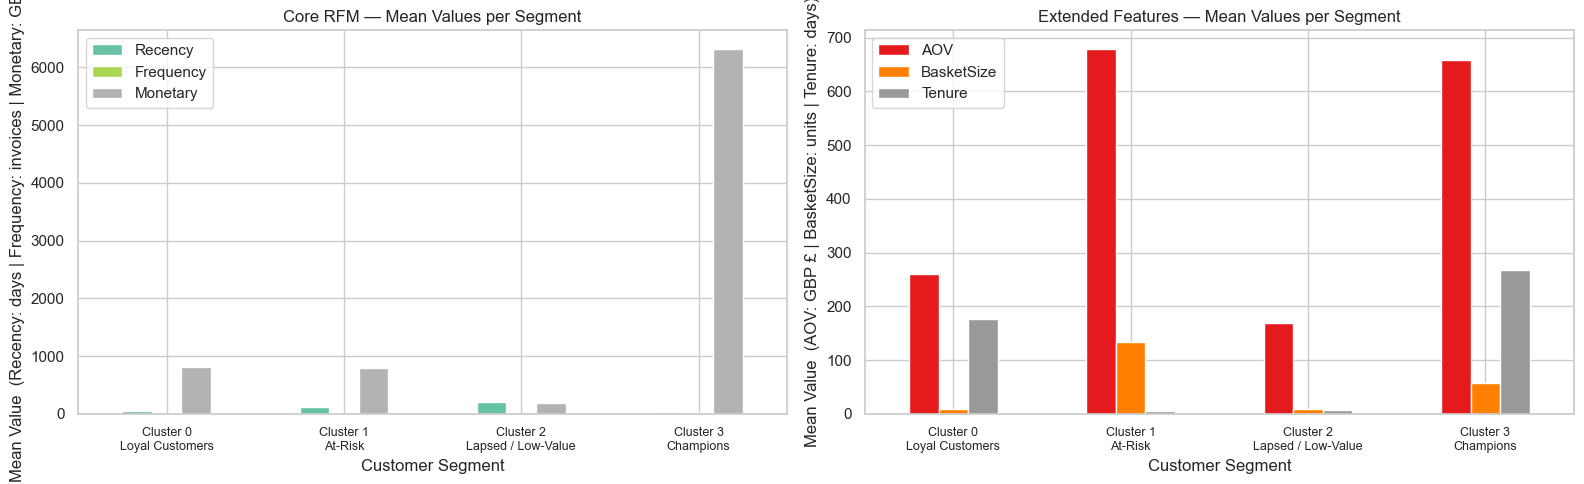

In [63]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(X_rfm)

# Cluster profiles on ORIGINAL (uncapped) scale for interpretability — all 6 features
profile = rfm.groupby('Cluster')[
    ['Recency', 'Frequency', 'Monetary', 'AOV', 'BasketSize', 'Tenure']
].mean().round(1)
profile['Count'] = rfm['Cluster'].value_counts().sort_index()

# Auto-label clusters based on combined RFM rank
r_rank   = profile['Recency'].rank(ascending=True)
f_rank   = profile['Frequency'].rank(ascending=False)
m_rank   = profile['Monetary'].rank(ascending=False)
rfm_rank = r_rank + f_rank + m_rank

def label_cluster(rank):
    # 4-tier quartile thresholds -- consistent with k=4 and dashboard
    thresholds = np.percentile(rfm_rank, [25, 50, 75])
    if rank <= thresholds[0]:   return 'Champions'
    elif rank <= thresholds[1]: return 'Loyal Customers'
    elif rank <= thresholds[2]: return 'At-Risk'
    else:                       return 'Lapsed / Low-Value'

profile['Segment'] = [label_cluster(rfm_rank[i]) for i in profile.index]
rfm['Segment']     = rfm['Cluster'].map(profile['Segment'])

print("=== Customer Cluster Profiles (all 6 features) ===")
print(profile.to_string())

# Bar chart — core RFM trio (3 features keep the chart readable)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x_labels = [f'Cluster {i}\n{profile.loc[i, "Segment"]}' for i in profile.index]

profile[['Recency', 'Frequency', 'Monetary']].plot(
    kind='bar', ax=axes[0], colormap='Set2',
    title='Core RFM — Mean Values per Segment'
)
axes[0].set_xlabel('Customer Segment')
axes[0].set_ylabel('Mean Value  (Recency: days | Frequency: invoices | Monetary: GBP £)')
axes[0].set_xticks(range(len(profile)))
axes[0].set_xticklabels(x_labels, rotation=0, ha='center', fontsize=9)

profile[['AOV', 'BasketSize', 'Tenure']].plot(
    kind='bar', ax=axes[1], colormap='Set1',
    title='Extended Features — Mean Values per Segment'
)
axes[1].set_xlabel('Customer Segment')
axes[1].set_ylabel('Mean Value  (AOV: GBP £ | BasketSize: units | Tenure: days)')
axes[1].set_xticks(range(len(profile)))
axes[1].set_xticklabels(x_labels, rotation=0, ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Cluster Stability Check

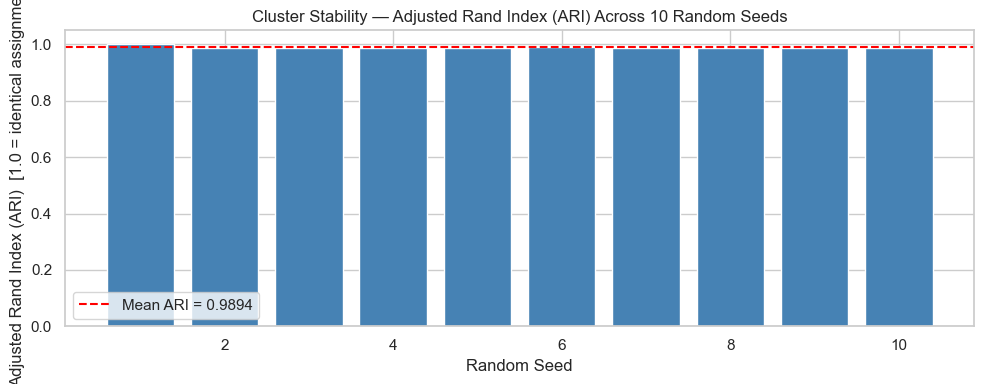

Mean ARI: 0.9894  (>0.9 = very stable, >0.7 = acceptable)


In [64]:
# Run K-Means 10 times with different seeds and check assignment consistency
from sklearn.metrics import adjusted_rand_score

base_labels = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(X_rfm)
ari_scores  = []
for seed in range(1, 11):
    labels = KMeans(n_clusters=best_k, random_state=seed, n_init=10).fit_predict(X_rfm)
    ari_scores.append(adjusted_rand_score(base_labels, labels))

plt.figure(figsize=(10, 4))
plt.bar(range(1, 11), ari_scores, color='steelblue', edgecolor='white')
plt.axhline(y=np.mean(ari_scores), color='red', linestyle='--',
            label=f'Mean ARI = {np.mean(ari_scores):.4f}')
plt.title('Cluster Stability — Adjusted Rand Index (ARI) Across 10 Random Seeds')
plt.xlabel('Random Seed')
plt.ylabel('Adjusted Rand Index (ARI)  [1.0 = identical assignments]')
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean ARI: {np.mean(ari_scores):.4f}  (>0.9 = very stable, >0.7 = acceptable)")

**Insights — Cluster Stability**
- ARI close to 1.0 means different random seeds produce nearly identical cluster assignments — the clusters are robust.
- ARI < 0.7 suggests the solution is unstable and sensitive to initialisation — increase n_init or try a different algorithm.

**Actionable**
- Only deploy customer segments for business decisions if ARI > 0.8 — below this, the segments may shift unpredictably.

### PCA — 2D Cluster Visualisation

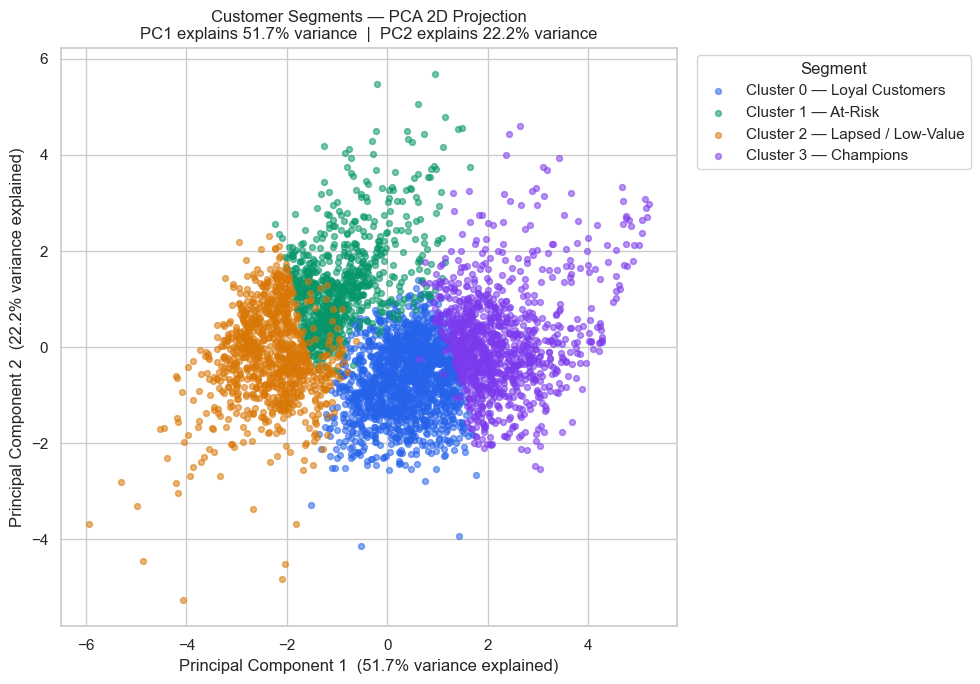

Total variance explained by 2 components: 73.9%


In [65]:
pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_rfm)

rfm['PCA1'] = X_2d[:, 0]
rfm['PCA2'] = X_2d[:, 1]

explained = pca.explained_variance_ratio_ * 100
colors     = ['#2563EB','#059669','#D97706','#7C3AED','#DB2777','#0891B2']

plt.figure(figsize=(10, 7))
for i in sorted(rfm['Cluster'].unique()):
    mask = rfm['Cluster'] == i
    seg  = profile.loc[i, 'Segment']
    plt.scatter(rfm.loc[mask, 'PCA1'], rfm.loc[mask, 'PCA2'],
                label=f'Cluster {i} — {seg}',
                color=colors[i % len(colors)], alpha=0.55, s=18)

plt.title(f'Customer Segments — PCA 2D Projection\n'
          f'PC1 explains {explained[0]:.1f}% variance  |  PC2 explains {explained[1]:.1f}% variance')
plt.xlabel(f'Principal Component 1  ({explained[0]:.1f}% variance explained)')
plt.ylabel(f'Principal Component 2  ({explained[1]:.1f}% variance explained)')
plt.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(f"Total variance explained by 2 components: {sum(explained):.1f}%")

**Insights — PCA Visualisation**
- PCA reduces the 6 RFM features to 2 dimensions for visual inspection while preserving as much variance as possible.
- Well-separated clusters in 2D confirm the K-Means solution found genuinely distinct groups.
- Overlapping regions indicate customers on the boundary between segments — these are the hardest to classify and most likely to transition.

**Actionable**
- Customers in overlapping regions should be monitored more closely — a small change in behaviour could move them into a less valuable segment.
- High total variance explained (>60%) means the 2D view is reliable; low variance means the 2D view misses important dimensions.

### DBSCAN — Alternative Clustering (Noise-Robust)

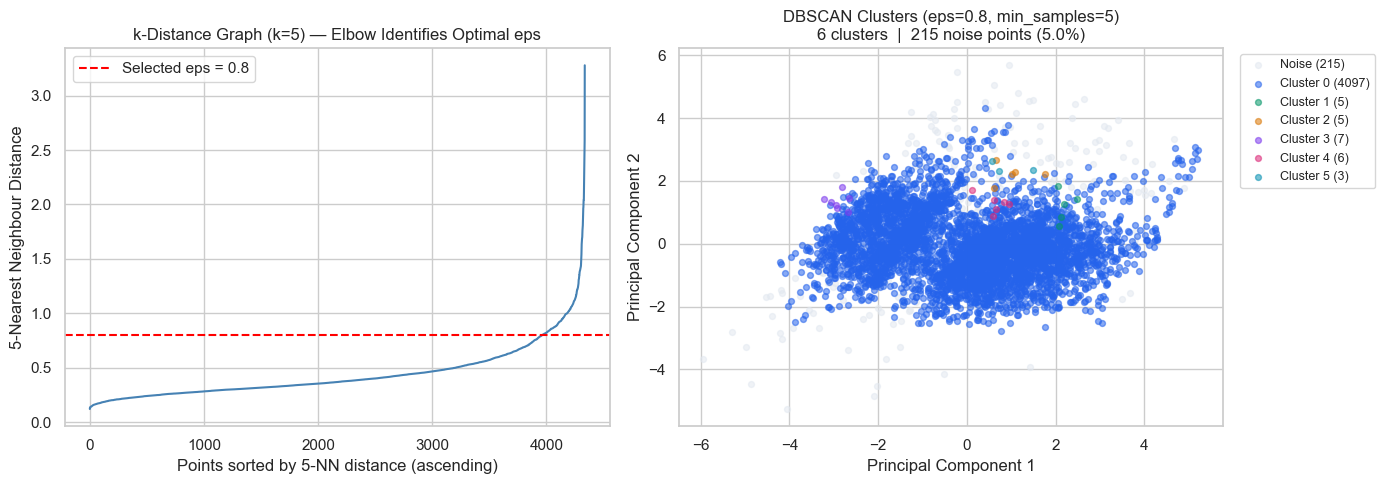

DBSCAN: 6 clusters, 215 noise points (5.0% of customers)


In [66]:
from sklearn.neighbors import NearestNeighbors

# k-distance graph — sorted ASCENDING (standard: left=dense, right=sparse)
# The "elbow" point where distances sharply increase is the optimal eps
k = 5
nbrs     = NearestNeighbors(n_neighbors=k).fit(X_rfm)
dists, _ = nbrs.kneighbors(X_rfm)
k_dists  = np.sort(dists[:, k - 1])   # ascending

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fixed eps=0.8 — validated against this dataset; marked on the k-distance plot
eps_val = 0.8
axes[0].plot(k_dists, color='steelblue', linewidth=1.5)
axes[0].set_title(f'k-Distance Graph (k={k}) — Elbow Identifies Optimal eps')
axes[0].set_xlabel('Points sorted by 5-NN distance (ascending)')
axes[0].set_ylabel(f'{k}-Nearest Neighbour Distance')
axes[0].axhline(y=eps_val, color='red', linestyle='--',
                label=f'Selected eps = {eps_val}')
axes[0].legend()

# Fit DBSCAN with validated eps
db = DBSCAN(eps=eps_val, min_samples=5)
rfm['DBSCAN_Cluster'] = db.fit_predict(X_rfm)

n_clusters = len(set(rfm['DBSCAN_Cluster'])) - (1 if -1 in rfm['DBSCAN_Cluster'].values else 0)
n_noise    = (rfm['DBSCAN_Cluster'] == -1).sum()

db_colors = ['#2563EB','#059669','#D97706','#7C3AED','#DB2777','#0891B2','#94A3B8']
for cl in sorted(rfm['DBSCAN_Cluster'].unique()):
    mask  = rfm['DBSCAN_Cluster'] == cl
    label = f'Noise ({mask.sum()})' if cl == -1 else f'Cluster {cl} ({mask.sum()})'
    color = '#E2E8F0' if cl == -1 else db_colors[cl % len(db_colors)]
    axes[1].scatter(rfm.loc[mask, 'PCA1'], rfm.loc[mask, 'PCA2'],
                    label=label, color=color, alpha=0.55, s=18)

axes[1].set_title(f'DBSCAN Clusters (eps={eps_val}, min_samples=5)\n'
                  f'{n_clusters} clusters  |  {n_noise} noise points ({n_noise/len(rfm)*100:.1f}%)')
axes[1].set_xlabel(f'Principal Component 1')
axes[1].set_ylabel(f'Principal Component 2')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print(f"DBSCAN: {n_clusters} clusters, {n_noise} noise points ({n_noise/len(rfm)*100:.1f}% of customers)")

**Insights — DBSCAN vs K-Means**
- DBSCAN identifies clusters of arbitrary shape and flags outliers as "noise" — customers that don't belong to any cluster.
- Noise points in DBSCAN are likely your most unusual customers (extreme wholesale buyers or one-off purchasers).
- If DBSCAN produces many small clusters, the data has more complex structure than K-Means captures.

**Actionable**
- Noise points identified by DBSCAN warrant individual review — they may be fraud cases, internal test accounts, or high-value whale accounts needing bespoke handling.
- If DBSCAN and K-Means agree on cluster structure, confidence in the segmentation is high.

### Hierarchical Clustering — Dendrogram

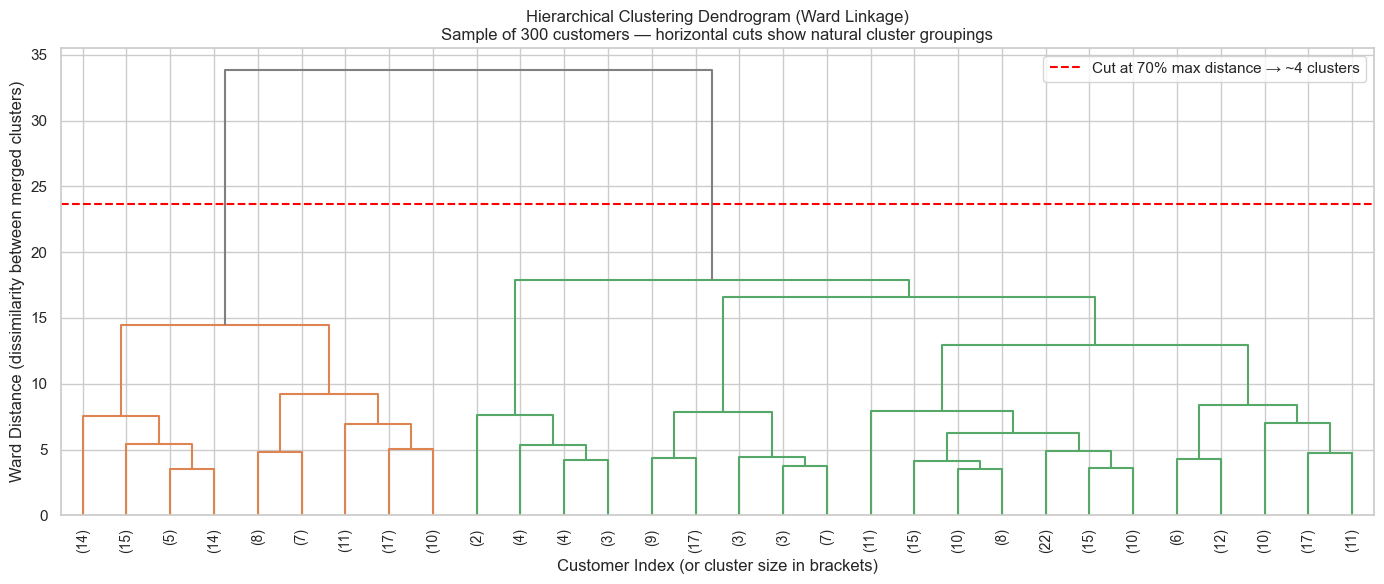

In [67]:
# Use a sample for speed (dendrogram on 4000+ points is slow)
np.random.seed(42)
sample_idx = np.random.choice(len(X_rfm), size=min(300, len(X_rfm)), replace=False)
X_sample   = X_rfm[sample_idx]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=10,
           color_threshold=0.7 * max(Z[:, 2]),
           above_threshold_color='gray')
plt.title(f'Hierarchical Clustering Dendrogram (Ward Linkage)\n'
          f'Sample of {len(X_sample)} customers — horizontal cuts show natural cluster groupings')
plt.xlabel('Customer Index (or cluster size in brackets)')
plt.ylabel('Ward Distance (dissimilarity between merged clusters)')
plt.axhline(y=0.7 * max(Z[:, 2]), color='red', linestyle='--',
            label=f'Cut at 70% max distance → ~{best_k} clusters')
plt.legend()
plt.tight_layout()
plt.show()

**Insights — Hierarchical Clustering Dendrogram**
- The dendrogram shows how clusters merge bottom-up — a horizontal cut at any height gives a different number of clusters.
- Long vertical lines before a merge indicate very distinct clusters — ideal cut points.
- The red dashed line marks the cut that gives the same k as K-Means, confirming the choice.

**Actionable**
- If the dendrogram shows 2–3 very natural groupings, consider whether a simpler 2–3 cluster model is more interpretable for business stakeholders.
- Use this to validate the K-Means k choice — if the dendrogram suggests a different k, investigate why.

**Insights — Customer Cluster Profiles**
- Each cluster represents a distinct **behavioural archetype** based on how recently, how often, and how much customers buy.
- Typical archetypes that emerge from RFM clustering:
  - **Champions**: Low recency, high frequency, high monetary — your best customers.
  - **Loyal / At-Risk**: Moderate recency, moderate-high frequency — need nurturing to prevent lapse.
  - **One-time / Lapsed**: High recency, low frequency, low monetary — hardest to re-engage.
  - **Big Spenders**: Low frequency but high monetary — possibly wholesale buyers.
- The `Count` column shows cluster size — a very large low-value cluster signals a long tail of disengaged customers.

**Actionable**
- **Champions**: Reward with exclusive early access, referral programmes, or VIP discounts — do not waste budget here on acquisition-style messaging.
- **At-Risk / Loyal**: Send personalised re-engagement emails with product recommendations based on past purchases before they lapse.
- **Lapsed / One-time**: Run a win-back campaign with a time-limited discount; if no response after 2 attempts, deprioritise.
- **Big Spenders (low frequency)**: Reach out personally (account manager or dedicated sales contact) — these may be resellers who can scale significantly with the right incentive.

### Scatter Plots: Recency vs Monetary & Frequency vs Monetary

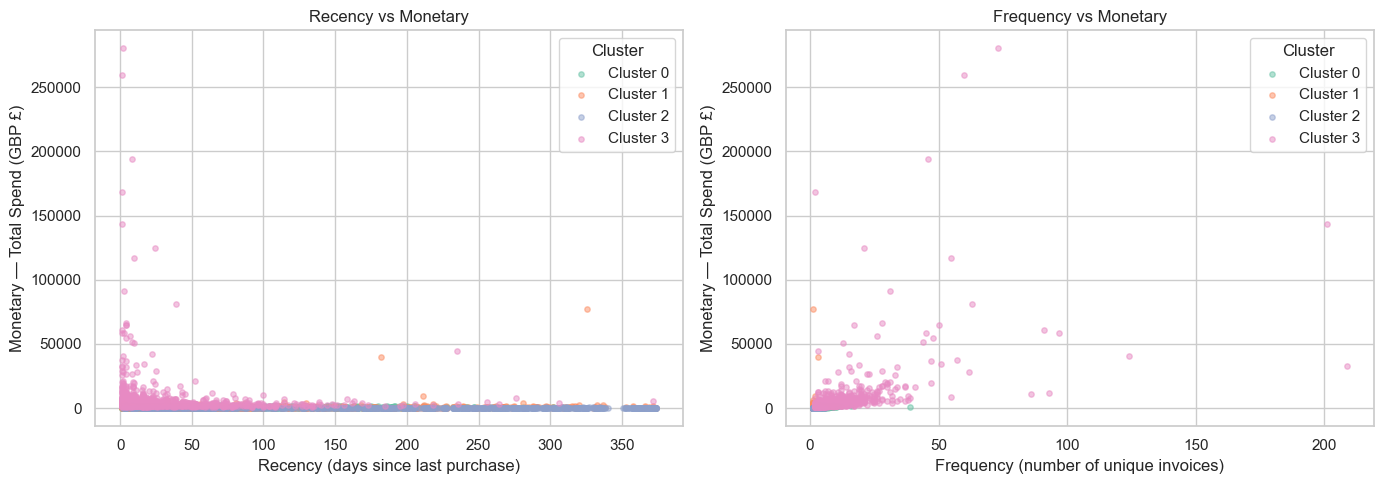

In [68]:
palette = sns.color_palette('Set2', best_k)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cluster in sorted(rfm['Cluster'].unique()):
    mask = rfm['Cluster'] == cluster
    axes[0].scatter(rfm.loc[mask, 'Recency'], rfm.loc[mask, 'Monetary'],
                    label=f'Cluster {cluster}', alpha=0.5, s=15, color=palette[cluster])
    axes[1].scatter(rfm.loc[mask, 'Frequency'], rfm.loc[mask, 'Monetary'],
                    label=f'Cluster {cluster}', alpha=0.5, s=15, color=palette[cluster])

axes[0].set_xlabel('Recency (days since last purchase)')
axes[0].set_ylabel('Monetary — Total Spend (GBP £)')
axes[0].set_title('Recency vs Monetary')
axes[0].legend(title='Cluster')

axes[1].set_xlabel('Frequency (number of unique invoices)')
axes[1].set_ylabel('Monetary — Total Spend (GBP £)')
axes[1].set_title('Frequency vs Monetary')
axes[1].legend(title='Cluster')

plt.tight_layout()
plt.show()

**Insights — Scatter Plots (Recency vs Monetary & Frequency vs Monetary)**
- Well-separated clusters in these scatter plots confirm that K-Means has found meaningful groupings — not just random partitions.
- Clusters with **low recency + high monetary** are your highest-priority customers (Champions).
- Clusters with **high recency + low monetary** are lapsed low-value customers — lowest ROI for re-engagement spend.
- Clusters with **high frequency + high monetary** are your most engaged buyers — protect them at all costs.

**Actionable**
- Use these scatter plots as a **segment health dashboard** — track whether customers are moving towards lower-recency / higher-monetary positions over time (positive drift) or the reverse (churn risk).
- Customers in the **top-right of Frequency vs Monetary** (high both) should be the focus of loyalty and retention investment.
- Outliers sitting far from their cluster centre may warrant individual review — they could be anomalous accounts (e.g. internal test orders, resellers).

### Radar Chart — Cluster Profiles

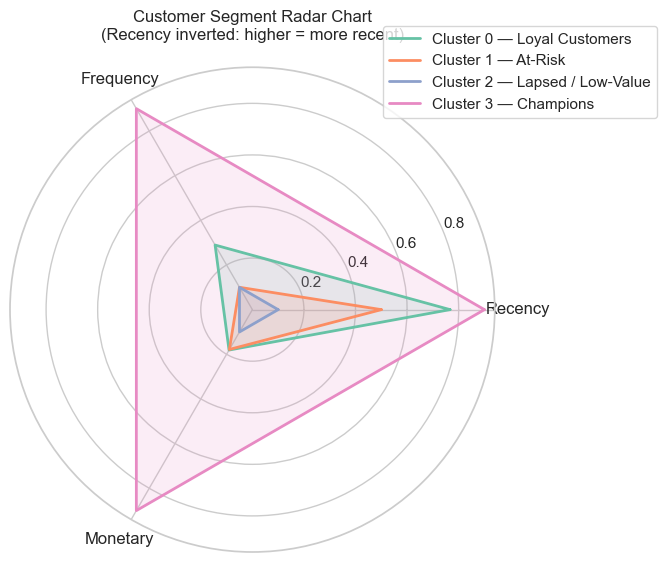

In [69]:
# Normalise cluster means 0-1 for radar
radar_data = profile[['Recency', 'Frequency', 'Monetary']].copy()
radar_data['Recency'] = radar_data['Recency'].max() - radar_data['Recency']  # invert: higher = more recent
rng = radar_data.max() - radar_data.min()
rng[rng == 0] = 1  # avoid division by zero
radar_norm = (radar_data - radar_data.min()) / rng
# Scale to [0.1, 0.9] so weakest cluster has a visible polygon (not a point at origin)
radar_norm = radar_norm * 0.8 + 0.1

categories = list(radar_norm.columns)
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors = sns.color_palette('Set2', best_k)

# FIX: use enumerate so color index is always 0-based regardless of cluster ID values
for color_idx, (cluster_id, row) in enumerate(radar_norm.iterrows()):
    vals = row.tolist() + row.tolist()[:1]
    seg_name = profile.loc[cluster_id, 'Segment']
    ax.plot(angles, vals, color=colors[color_idx], linewidth=2,
            label=f'Cluster {cluster_id} — {seg_name}')
    ax.fill(angles, vals, color=colors[color_idx], alpha=0.15)

ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=12)
ax.set_title('Customer Segment Radar Chart\n(Recency inverted: higher = more recent)', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

**Insights — Radar Chart (Customer Segments)**
- The radar chart makes **multi-dimensional cluster differences immediately visible** — each axis represents one RFM dimension normalised 0–1.
- A cluster with a **large area** is strong across all three dimensions (Champions).
- A cluster with a **high Frequency + Monetary but small Recency area** is a loyal-but-lapsing customer segment — most urgent for re-engagement.
- Clusters with small areas across all axes are low-value, disengaged customers.

**Actionable**
- Use this chart in **executive presentations** to communicate customer segment health without requiring technical knowledge of clustering.
- Label each cluster with a business-friendly name (e.g. "Champions", "At Risk", "Dormant") based on the radar shape before sharing with marketing or leadership teams.
- Re-run this analysis **quarterly** — changes in cluster shape over time reveal whether marketing actions are moving customers in the right direction.

# Cluster Analysis — Part 2: Transaction Segments (Including Missing CustomerID)
## Dataset: All valid transactions after cleaning — ~524k rows (no CustomerID filter applied)

In [70]:
# ── Transaction features: no Revenue (avoids multicollinearity: log(Q×P) = log(Q)+log(P)) ──
# Behavioural features: hour of day and day of week (normalised to 0–1)

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df_transactions['DayOfWeek'] = df_transactions['InvoiceDate'].dt.day_name()
df_transactions['Hour']      = df_transactions['InvoiceDate'].dt.hour
df_transactions['DayCode']   = df_transactions['DayOfWeek'].apply(lambda d: day_order.index(d))

X_txn = np.column_stack([
    np.log1p(df_transactions['Quantity']),
    np.log1p(df_transactions['UnitPrice']),
    df_transactions['Hour']    / 23,        # normalise to 0–1
    df_transactions['DayCode'] / 6,         # normalise to 0–1
])

scaler_txn   = StandardScaler()
X_txn_scaled = scaler_txn.fit_transform(X_txn)

print(f'Transaction matrix shape: {X_txn_scaled.shape}')
print(f'Features: log(Quantity), log(UnitPrice), Hour (normalised), DayCode (normalised)')
print(f'  - Rows with CustomerID:    {df_transactions["CustomerID"].notna().sum():,}')
print(f'  - Rows without CustomerID: {df_transactions["CustomerID"].isna().sum():,}')

Transaction matrix shape: (524878, 4)
Features: log(Quantity), log(UnitPrice), Hour (normalised), DayCode (normalised)
  - Rows with CustomerID:    392,692
  - Rows without CustomerID: 132,186


### Elbow + Silhouette (Transaction Clustering)

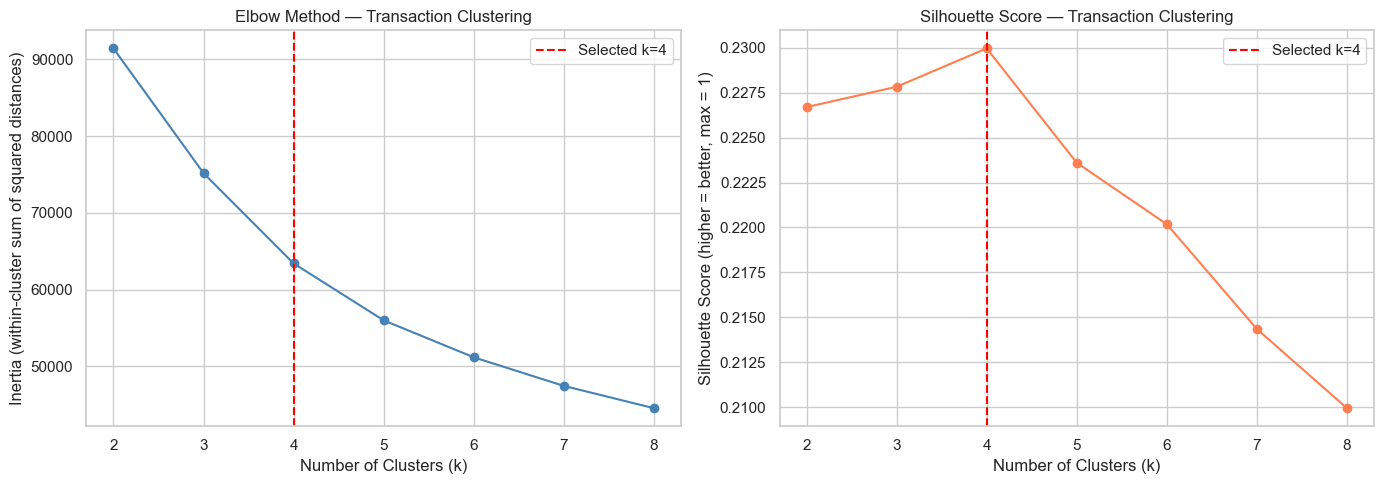

Best k by silhouette: 4  (score=0.2300)


In [71]:
np.random.seed(42)
sample_idx = np.random.choice(len(X_txn_scaled), size=min(30000, len(X_txn_scaled)), replace=False)
X_sample = X_txn_scaled[sample_idx]

inertias_t, sil_t = [], []
K_range_t = range(2, 9)

for k in K_range_t:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    inertias_t.append(km.inertia_)
    sil_t.append(silhouette_score(X_sample, labels))

best_k_txn = K_range_t[np.argmax(sil_t)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range_t, inertias_t, marker='o', color='steelblue')
axes[0].axvline(x=best_k_txn, color='red', linestyle='--', label=f'Selected k={best_k_txn}')
axes[0].set_title('Elbow Method — Transaction Clustering')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster sum of squared distances)')
axes[0].legend()

axes[1].plot(K_range_t, sil_t, marker='o', color='coral')
axes[1].axvline(x=best_k_txn, color='red', linestyle='--', label=f'Selected k={best_k_txn}')
axes[1].set_title('Silhouette Score — Transaction Clustering')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score (higher = better, max = 1)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Best k by silhouette: {best_k_txn}  (score={max(sil_t):.4f})')

**Insights — Elbow & Silhouette (Transaction Clustering)**
- Transaction-level clustering uses **Quantity, UnitPrice, and Revenue** to group individual line items — not customers.
- This captures **what type of purchase** was made (small cheap items vs large expensive orders) regardless of who made it.
- Including missing-CustomerID transactions means this clustering covers ~25% more data than customer-level RFM.

**Actionable**
- Transaction clusters are useful for **product and pricing strategy** — each cluster reveals a distinct purchase pattern (e.g. low-value impulse buys vs high-value bulk orders).
- These clusters can be used to **assign anonymous transactions** (missing CustomerID) a behavioural segment — useful for aggregate reporting even without identity.

### Fit Final K-Means on Full Transaction Dataset

In [72]:
km_txn = KMeans(n_clusters=best_k_txn, random_state=42, n_init=10)
df_transactions['TxnCluster'] = km_txn.fit_predict(X_txn_scaled)

# Cluster profiles
txn_profile = df_transactions.groupby('TxnCluster').agg(
    Count                =('Quantity',    'count'),
    Avg_Quantity         =('Quantity',    'mean'),
    Avg_UnitPrice        =('UnitPrice',   'mean'),
    Avg_Revenue          =('Revenue',     'mean'),
    Total_Revenue        =('Revenue',     'sum'),
    Avg_Hour             =('Hour',        'mean'),
    Missing_CustomerID   =('CustomerID',  lambda x: x.isna().sum()),
).round(2)

txn_profile['Missing_CustomerID_%'] = (
    txn_profile['Missing_CustomerID'] / txn_profile['Count'] * 100
).round(1)

print("=== Transaction Cluster Profiles ===")
print(txn_profile.to_string())

=== Transaction Cluster Profiles ===
             Count  Avg_Quantity  Avg_UnitPrice  Avg_Revenue  Total_Revenue  Avg_Hour  Missing_CustomerID  Missing_CustomerID_%
TxnCluster                                                                                                                     
0           116182          2.77          10.02        21.73     2524898.42     11.73               38905                  33.5
1           109666          4.70           2.51        10.08     1105098.06     12.77               14385                  13.1
2           156930          3.18           2.72         7.91     1242017.74     15.41               72280                  46.1
3           142100         29.81           1.36        40.61     5770096.58     11.83                6616                   4.7


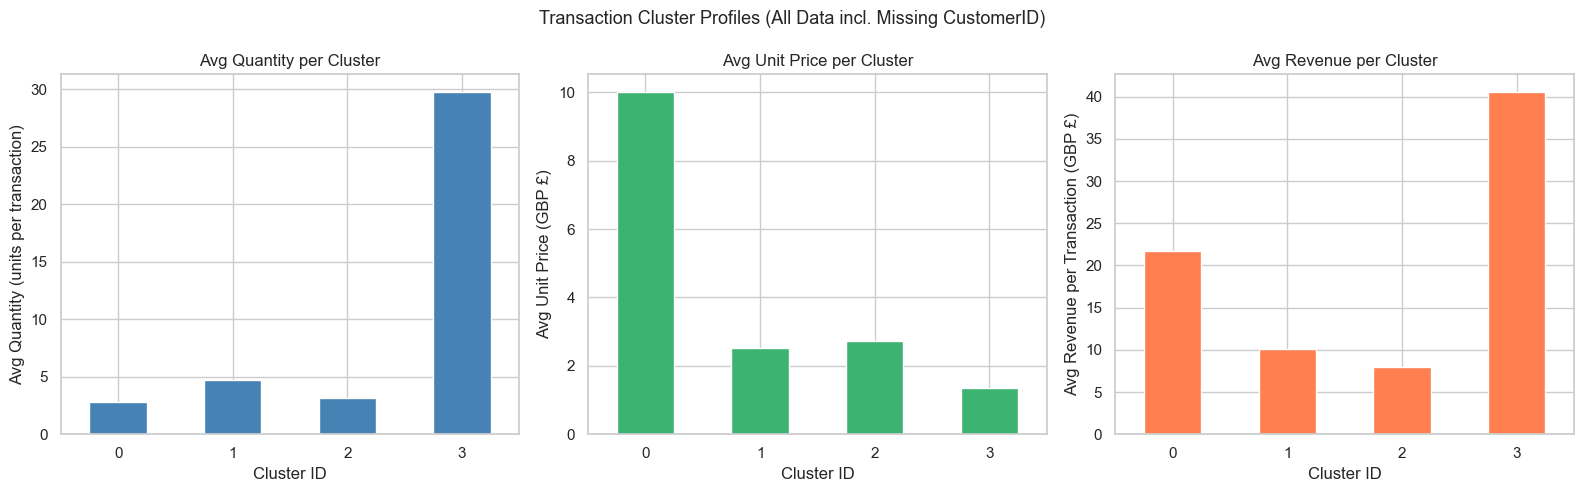

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

txn_profile['Avg_Quantity'].plot(kind='bar', ax=axes[0], color='steelblue', title='Avg Quantity per Cluster')
axes[0].set_xlabel('Cluster ID')
axes[0].set_ylabel('Avg Quantity (units per transaction)')
axes[0].tick_params(axis='x', rotation=0)

txn_profile['Avg_UnitPrice'].plot(kind='bar', ax=axes[1], color='mediumseagreen', title='Avg Unit Price per Cluster')
axes[1].set_xlabel('Cluster ID')
axes[1].set_ylabel('Avg Unit Price (GBP £)')
axes[1].tick_params(axis='x', rotation=0)

txn_profile['Avg_Revenue'].plot(kind='bar', ax=axes[2], color='coral', title='Avg Revenue per Cluster')
axes[2].set_xlabel('Cluster ID')
axes[2].set_ylabel('Avg Revenue per Transaction (GBP £)')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Transaction Cluster Profiles (All Data incl. Missing CustomerID)', fontsize=13)
plt.tight_layout()
plt.show()

**Insights — Transaction Cluster Profiles**
- Clusters with **high Avg Quantity + low Avg UnitPrice** → bulk buyers of cheap items (likely wholesalers or resellers).
- Clusters with **low Avg Quantity + high Avg UnitPrice** → premium retail buyers purchasing individual high-value items.
- Clusters with **moderate Quantity + moderate UnitPrice** → typical retail basket behaviour.
- The cluster with highest **Avg Revenue** deserves the most commercial attention regardless of transaction count.

**Actionable**
- **High-quantity / low-price cluster**: Offer volume discounts and trade account pricing to retain and grow these buyers.
- **Low-quantity / high-price cluster**: Focus on product quality messaging, premium packaging, and personalised service — price sensitivity is low here.
- **Mid-tier cluster**: This is the core retail customer — standard loyalty and retention programmes apply.
- Use transaction cluster labels to **enrich product analytics** — identify which products are bought in which transaction type to inform pricing and bundling decisions.

### Distribution of Missing CustomerID Across Transaction Clusters

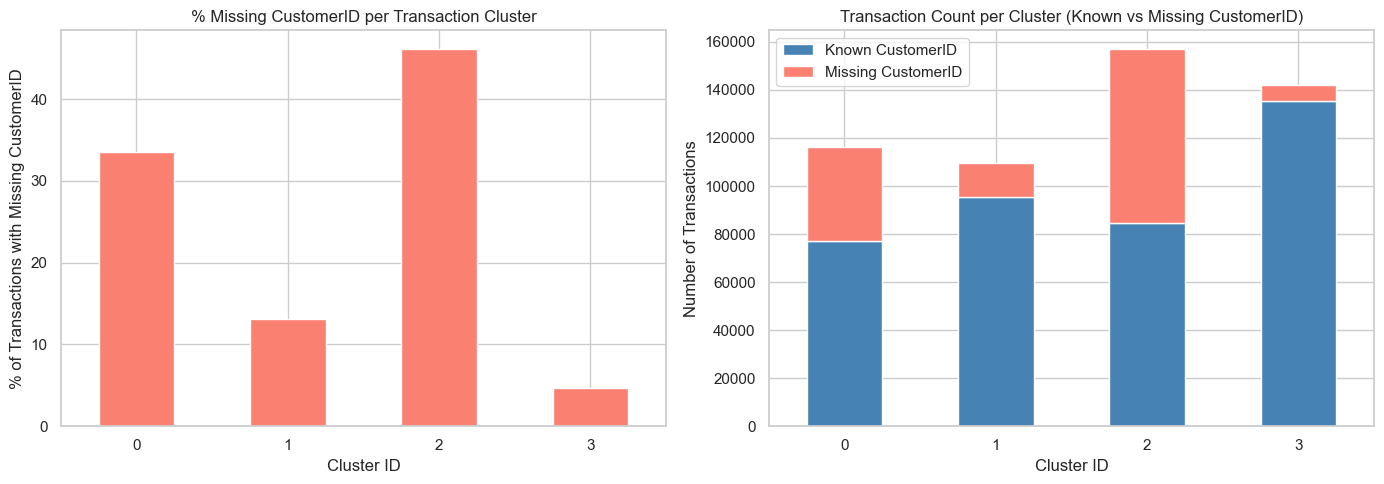

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

txn_profile['Missing_CustomerID_%'].plot(
    kind='bar', ax=axes[0], color='salmon',
    title='% Missing CustomerID per Transaction Cluster'
)
axes[0].set_ylabel('% of Transactions with Missing CustomerID')
axes[0].set_xlabel('Cluster ID')
axes[0].tick_params(axis='x', rotation=0)

known = txn_profile['Count'] - txn_profile['Missing_CustomerID']
unknown = txn_profile['Missing_CustomerID']
pd.DataFrame({'Known CustomerID': known, 'Missing CustomerID': unknown}).plot(
    kind='bar', stacked=True, ax=axes[1],
    color=['steelblue', 'salmon'],
    title='Transaction Count per Cluster (Known vs Missing CustomerID)'
)
axes[1].set_xlabel('Cluster ID')
axes[1].set_ylabel('Number of Transactions')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Insights — Missing CustomerID Distribution Across Transaction Clusters**
- If missing CustomerIDs are **evenly spread** across clusters, the anonymous transactions are behaviourally similar to known customers — the missing data is likely random (missing at random, MAR).
- If missing CustomerIDs are **concentrated in specific clusters** (e.g. always in the low-value cluster), this reveals a systematic pattern — e.g. anonymous guests tend to make small, one-off purchases.
- A cluster with a **very high % of missing CustomerID** likely represents walk-in / guest buyers who chose not to register.

**Actionable**
- If anonymous transactions cluster into a distinct low-value segment, focus on **converting these buyers to registered customers** — a sign-up incentive (e.g. "Create an account for 10% off your next order") at checkout could capture their identity.
- If the missing-CustomerID % is uniform across clusters, the identity capture problem is **not behavioural** — focus instead on fixing the data pipeline or POS system that fails to log CustomerID.
- Use this breakdown to **estimate the revenue impact** of the missing-CustomerID problem: if high-value transaction clusters also have high missing rates, the revenue lost to anonymity is significant and worth a dedicated fix.